![Project Diagram](Violence_image.jpeg)

# Predicting the Severity of Political Violence in Kenya
*A Machine Learning Approach Using Historical Conflict Fatality Data*

---
**Team:**(Ctrl-Alt-Elite)  
**Contributors:** Kimutai Kevine, Mercy Wambui, Jackline Mwau, Richard Oketch, Winnie Nduva, Reeves Gonah  
**Date:** June - July 2026  
**Project:** Capstone Project  
**Data Sources:** [ACLED Africa Aggregated Conflict Dataset](https://acleddata.com/aggregated/aggregated-data-africa) | [WorldPop Population-Weighted Density Dataset](https://hub.worldpop.org/geodata/summary?id=50573)

---


## Abstract

This notebook documents the end-to-end pipeline for predicting the severity of political violence — measured as fatality counts — across Kenya's 47 counties at weekly resolution. The project combines nearly three decades of granular conflict event data from the Armed Conflict Location & Event Data (ACLED) project (1997–2026) with county-level demographic structure drawn from WorldPop population-weighted density estimates, interpolated across all years using inter-censal growth rates from the Kenya National Bureau of Statistics (KNBS).

The notebook is organised according to the CRISP-DM framework and covers: business understanding, dataset creation (including the population merge and interpolation pipeline), and data preparation (cleaning, missing value treatment, and initial feature engineering). Modelling, evaluation, and deployment follow in subsequent sections.

---


## 1. Business Understanding

---


### 1.1 Background

Kenya has experienced recurring episodes of political violence since the early 1990s, with the most severe flashpoints clustered around contested general elections — most notably the 2007/08 post-election crisis and the 2017 repeat presidential election. Political violence in Kenya is frequently linked to ethnic mobilisation, contested results, and localised historical grievances that resurface predictably around electoral cycles.

Despite this recurring pattern, conflict response in Kenya has historically been **reactive rather than predictive**. Security deployments, mediation efforts, and humanitarian pre-positioning tend to follow violence rather than anticipate it. This is not due to a lack of data — organisations like ACLED have systematically tracked conflict events, locations, actors, and fatalities across Kenya for nearly three decades. The gap is in **translating that raw event data into structured, actionable, forward-looking risk intelligence** at a level decision-makers can use: the county.


### 1.2 Business Problem

Political violence in Kenya is not random — it is patterned by geography, event type, population density, and temporal cycles aligned with elections and resource conflicts. Despite this predictability, early warning systems and humanitarian resource allocation in Kenya continue to rely primarily on expert judgement and lagged reporting, rather than systematic, data-driven forecasting.

**Formally, the business problem is:**

> Given historical patterns of conflict events, fatalities, and county-level demographic structure, can we predict the *severity* of political violence (fatalities) at the county-week level — well enough to flag high-risk counties before violence escalates, and to explain *why* those counties are at risk in terms decision-makers can act on?

**Why this is a hard problem:** the target variable, `FATALITIES` per county-week, is heavily right-skewed — 72.6% of observations are zero, while the maximum recorded value is 281 fatalities in a single county-week. Predicting rare, high-impact outcomes from a sparse and noisy signal is both analytically non-trivial and practically urgent.


### 1.3 Objectives

1. Identify statistically significant predictors of fatalities using feature importance scores and correlation analysis.
2. Quantify the marginal effect of population and density features on predicted fatality counts.
3. Build and evaluate four supervised regression models — Linear Regression, Random Forest, XGBoost, and Gradient Boosting — ranked by MAE, RMSE, and R² on a held-out test set.
4. Produce a county-level vulnerability index ranking all 47 counties by predicted high-fatality risk.
5. Deliver interpretable SHAP-based feature importance mapped to actionable policy recommendations.


### 1.4 Research Questions

1. Which features (event type, county, population density, temporal patterns) are the most statistically significant predictors of conflict fatalities?
2. What is the marginal effect of population and density on predicted fatality counts, independent of event-type effects?
3. Which of the four models best predicts fatality counts as measured by MAE, RMSE, and R² on the held-out test set?
4. Which of Kenya's 47 counties carry the highest predicted risk of severe political violence, and does this align with known historical hotspots?
5. According to SHAP value analysis, which features contribute most to predicted fatality severity, and what actionable policy recommendations can be derived from them?


### 1.5 Success Metrics

| Metric | Purpose |
|---|---|
| MAE | Average error in original fatality units; robust to outliers |
| RMSE | Penalises large misses heavily — important given the high-fatality tail |
| Poisson deviance | Primary goodness-of-fit measure — matches the `count:poisson` objective used for the zero-inflated, over-dispersed target, unlike R² |

**Additional success criteria (in priority order):**
1. County-level vulnerability rankings correctly surface known real-world hotspots (Turkana, Nairobi, Mandera, Garissa) in the top tier of the ranking — the direct measure of whether the tool serves its actual purpose (Section 1.2)
2. Predicted-risk deciles show a monotonic calibration relationship with actual mean fatalities (i.e. higher predicted risk really does mean higher observed risk, on average) — the appropriate bar for a zero-inflated target, where exact-count accuracy is unrealistic
3. The best model's Poisson deviance beats a naive county-average baseline (predicting each county's historical mean fatalities)
4. RMSE improves on the Linear Regression baseline by ≥ 20%
5. Feature importance outputs align with domain knowledge


---
## 2. Dataset Creation
---


### 2.0 Library Imports
Importing the necessary libraries.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_poisson_deviance
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

print('Libraries loaded.')


Libraries loaded.


### 2.1 ACLED Kenya Conflict Data

The [Armed Conflict Location & Event Data (ACLED) dataset](https://acleddata.com/aggregated/aggregated-data-africa) was downloaded from the ACLED website, covering all of Africa from 1997 to June 2026.

**Pre-filtering note:** Prior to loading into this notebook, the full Africa file was filtered in Excel to retain only rows where `COUNTRY = 'Kenya'`, reducing the working file to 16,628 rows. This step was done purely for file size manageability and does not affect any analytical decisions — all subsequent transformations are performed here and are fully reproducible.


In [2]:
# Load pre-filtered ACLED Kenya file
acled = pd.read_csv('Africa_aggregated_data.csv')

print(f'ACLED Kenya rows: {len(acled):,}')
print(f'Columns: {acled.columns.tolist()}')
print(f'Counties: {acled["ADMIN1"].nunique()} unique counties')

ACLED Kenya rows: 16,627
Columns: ['WEEK', 'REGION', 'COUNTRY', 'ADMIN1', 'EVENT_TYPE', 'SUB_EVENT_TYPE', 'EVENTS', 'FATALITIES', 'POPULATION_EXPOSURE', 'DISORDER_TYPE', 'ID', 'CENTROID_LATITUDE', 'CENTROID_LONGITUDE']
Counties: 47 unique counties


In [3]:
# Preview the first few rows
acled.head()

,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE
0,24-January-1998,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185
1,16-January-1999,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185
2,25-September-1999,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185
3,07-August-2004,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,1,NaN,Political violence,1535,0.7197,36.0185
4,02-April-2005,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185


### 2.2 Validate and Parse Dates

Verifying the `WEEK` column is correctly parsed as a datetime and extracting `YEAR` for use in the population merge.


In [4]:
# Ensure WEEK is in datetime format
acled['WEEK'] = pd.to_datetime(acled['WEEK'])

# Extract YEAR from WEEK (overwrite the existing YEAR column to ensure consistency)
acled['YEAR'] = acled['WEEK'].dt.year

print(f'Year range: {acled["YEAR"].min()} to {acled["YEAR"].max()}')

Year range: 1997 to 2026


### 2.3 WorldPop Population-Weighted Density (PWD) Data

The WorldPop PWD dataset provides county-level population and density estimates for Kenya at five census snapshots: 2000, 2005, 2010, 2015, and 2020. Each snapshot was originally a separate workbook, consolidated into one CSV and filtered for Kenya.

**Columns selected and why:**

| Column | What it represents |
|---|---|
| `Pop` | Total county population — used for normalisation and as a raw feature |
| `Density` | People per km² — raw density, interpretable and widely used |
| `Area` | County area in km² — large sparse counties behave differently from small dense ones |
| `PWD_G` | Population-weighted density (geometric mean) — reflects how densely people actually live, not just the county average over empty land |
| `PWD_D10` | Top density decile — captures whether a county has a concentrated urban core |


In [5]:
PWD_FILE = 'PWD_2020-2000_sub_national_100m.csv'

# The five columns we want — theoretically motivated and non-redundant
PWD_COLS = ['year', 'Adm_N', 'Pop', 'Density', 'Area', 'PWD_G', 'PWD_D10']
pwd_raw = pd.read_csv(PWD_FILE, usecols=PWD_COLS)

print(f'Stacked PWD table: {pwd_raw.shape[0]} rows ({pwd_raw["year"].nunique()} years x {pwd_raw["Adm_N"].nunique()} counties)')
pwd_raw.head(10)

Stacked PWD table: 235 rows (5 years x 47 counties)


,year,Adm_N,Pop,Density,Area,PWD_G,PWD_D10
0,2020,Baringo,772211,72.0,10718.1,135.5,13704.2
1,2020,Bomet,1066552,446.5,2388.7,594.7,9975.2
2,2020,Bungoma,2050866,571.4,3589.1,796.2,12482.1
3,2020,Busia,936016,562.1,1665.2,676.7,11317.2
4,2020,Elgeyo-Marakwet,496199,176.2,2815.6,252.2,3153.8
5,2020,Embu,635018,225.7,2814.2,443.6,20263.5
6,2020,Garissa,1522617,34.6,44043.9,367.0,36448.2
7,2020,Homa Bay,1163389,377.3,3083.4,511.3,13802.0
8,2020,Isiolo,184769,7.2,25551.4,82.9,11453.6
9,2020,Kajiado,984921,45.0,21909.9,340.4,37552.6


**Note:**  

The PWD data only has values at 5 census snapshots (2000, 2005, 2010, 2015, 2020). We need a population value for every county in every year covered by ACLED (1997–2026). The approach is:

1. Standardise county names to match ACLED exactly
2. Build a full county × year grid (47 counties × 30 years = 1,410 rows)
3. Place known census values at the snapshot years
4. **Interpolate linearly** between known years — population grows continuously, not in 5-year steps
5. **Backfill** years before 2000 using the 2000 value (earliest available data)
6. **Extrapolate** years after 2020 using Kenya's 2009–2019 inter-censal growth rate of **2.2%** per year, as published in the 2019 Kenya Population and Housing Census (KNBS Volume I, Figure 2.2)


### 2.4 Standardise County Names

Two counties have different naming conventions between ACLED and WorldPop:

| WorldPop name | ACLED name |
|---|---|
| Elgeyo-Marakwet | Elgeyo Marakwet |
| Murang'a | Muranga |

Standardising PWD names to match ACLED so the merge works cleanly.


In [6]:
# Rename PWD county names to match ACLED
county_name_map = {
    'Elgeyo-Marakwet': 'Elgeyo Marakwet',
    "Murang'a":         'Muranga'
}
pwd_raw['Adm_N'] = pwd_raw['Adm_N'].replace(county_name_map)

# Confirm all PWD counties now match ACLED
acled_counties = set(acled['ADMIN1'].unique())
pwd_counties   = set(pwd_raw['Adm_N'].unique())

unmatched = acled_counties.symmetric_difference(pwd_counties)
if unmatched:
    print(f'WARNING — unmatched counties: {unmatched}')
else:
    print(f'All {len(acled_counties)} county names match between ACLED and PWD.')


All 47 county names match between ACLED and PWD.


### 2.5 Build the Full County × Year Grid


In [7]:
# All 47 counties and every year from 1997 to 2026
all_counties = sorted(pwd_raw['Adm_N'].unique())
all_years    = list(range(1997, 2027))

# Create a grid of every county-year combination
grid = pd.MultiIndex.from_product(
    [all_counties, all_years],
    names=['Adm_N', 'year']
).to_frame(index=False)

print(f'Full county-year grid: {len(grid):,} rows ({len(all_counties)} counties x {len(all_years)} years)')


Full county-year grid: 1,410 rows (47 counties x 30 years)


In [8]:
# Merge the known census values onto the grid
# Rows without a census snapshot will have NaN for population columns
pwd_grid = grid.merge(pwd_raw, on=['Adm_N', 'year'], how='left')

print(f'Grid after merging census values: {pwd_grid.shape}')
print(f'Rows with known population: {pwd_grid["Pop"].notna().sum()} (should be 47 x 5 = 235)')
print(f'Rows needing interpolation: {pwd_grid["Pop"].isna().sum()}')


Grid after merging census values: (1410, 7)
Rows with known population: 235 (should be 47 x 5 = 235)
Rows needing interpolation: 1175


### 2.6 Interpolate, Backfill, and Extrapolate

For each county separately:
- **Between 2000 and 2020**: linear interpolation between the 5 known census values
- **Before 2000**: backfill with the 2000 value (earliest available data)
- **After 2020**: apply 2.2% compound annual growth rate from the KNBS 2019 Census

This applies to all 5 PWD columns consistently.


In [9]:
PWD_VALUE_COLS = ['Pop', 'Density', 'Area', 'PWD_G', 'PWD_D10']
GROWTH_RATE = 0.022  # 2.2% per year — KNBS 2019 Census inter-censal rate 2009-2019

def fill_county_population(group):
    """
    For a single county's year series:
    1. Interpolate linearly between known census years
    2. Backfill years before 2000 with the 2000 value
    3. Extrapolate years after 2020 using 2.2% compound annual growth
    """
    group = group.sort_values('year').copy()
    for col in PWD_VALUE_COLS:
        # Step 1: linear interpolation between known census snapshots
        group[col] = group[col].interpolate(method='linear', limit_area='inside')
        # Step 2: backfill years before 2000 using the earliest known value
        group[col] = group[col].bfill()
        # Step 3: extrapolate years after 2020 using compound growth
        base_mask = group['year'] == 2020
        if base_mask.any():
            base_value = group.loc[base_mask, col].values[0]
            post_mask  = group['year'] > 2020
            years_after = group.loc[post_mask, 'year'] - 2020
            group.loc[post_mask, col] = base_value * ((1 + GROWTH_RATE) ** years_after.values)
    return group


In [10]:
# Apply county by county
pwd_filled = (
    pwd_grid
    .groupby('Adm_N', group_keys=True)
    .apply(fill_county_population, include_groups=False)
    .reset_index(level=0)
    .reset_index(drop=True)
)

# Verify no NaN values remain
remaining_nulls = pwd_filled[PWD_VALUE_COLS].isna().sum()
print('Remaining NaN values per column after interpolation:')
print(remaining_nulls)
print(f'\nTotal rows in reference table: {len(pwd_filled):,}')


Remaining NaN values per column after interpolation:
Pop        0
Density    0
Area       0
PWD_G      0
PWD_D10    0
dtype: int64

Total rows in reference table: 1,410


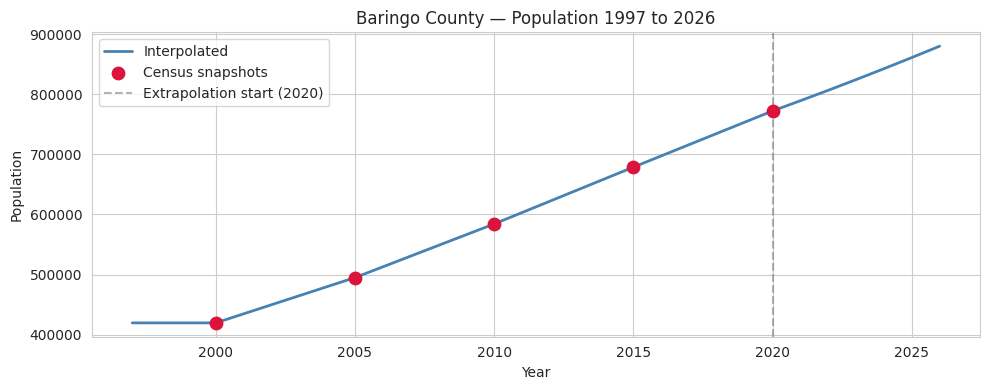

In [11]:
# Sanity check — plot Baringo population to confirm smooth interpolation
baringo = pwd_filled[pwd_filled['Adm_N'] == 'Baringo'].sort_values('year')
census_years = [2000, 2005, 2010, 2015, 2020]
baringo_census = baringo[baringo['year'].isin(census_years)]

plt.figure(figsize=(10, 4))
plt.plot(baringo['year'], baringo['Pop'], color='steelblue', linewidth=2, label='Interpolated')
plt.scatter(baringo_census['year'], baringo_census['Pop'],
            color='crimson', zorder=5, s=80, label='Census snapshots')
plt.axvline(2020, color='gray', linestyle='--', alpha=0.6, label='Extrapolation start (2020)')
plt.title('Baringo County — Population 1997 to 2026')
plt.xlabel('Year')
plt.ylabel('Population')
plt.legend()
plt.tight_layout()
plt.show()


**Note:**  
Red dots = known census values. Blue line = interpolated/extrapolated smoothly between them. The dashed line marks where 2.2% annual extrapolation begins.


### 2.7 Merge Population Features onto ACLED

Attaching the 5 population features to each ACLED row using a **left merge** on county name and year.

A left merge because:
- Every ACLED row is kept, regardless of whether a matching population row exists
- Population values are attached where county + year matches
- Counties that had no conflict events in a given year simply do not appear in ACLED and do not need a row in the merged dataset


In [12]:
# Prepare the reference table for merging
pwd_merge = pwd_filled[['Adm_N', 'year'] + PWD_VALUE_COLS].copy()
pwd_merge = pwd_merge.rename(columns={'Adm_N': 'ADMIN1', 'year': 'YEAR'})

# Rename columns to make them clearly identifiable in the merged dataset
pwd_merge = pwd_merge.rename(columns={
    'Pop':     'PWD_POPULATION',
    'Density': 'PWD_DENSITY',
    'Area':    'PWD_AREA_KM2',
    'PWD_G':   'PWD_G',
    'PWD_D10': 'PWD_D10'
})

print('Population reference table ready for merge:')
print(f'  Shape: {pwd_merge.shape}')
print(f'  Columns: {pwd_merge.columns.tolist()}')


Population reference table ready for merge:
  Shape: (1410, 7)
  Columns: ['ADMIN1', 'YEAR', 'PWD_POPULATION', 'PWD_DENSITY', 'PWD_AREA_KM2', 'PWD_G', 'PWD_D10']


In [13]:
# Perform the merge
rows_before = len(acled)
df = acled.merge(pwd_merge, on=['ADMIN1', 'YEAR'], how='left')
rows_after  = len(df)

print(f'Rows before merge: {rows_before:,}')
print(f'Rows after merge:  {rows_after:,}')
print(f'Row count preserved: {rows_before == rows_after}')
print()

# Check for any rows that did not get a population value
unmatched = df['PWD_POPULATION'].isna().sum()
print(f'Rows without population after merge: {unmatched}')


Rows before merge: 16,627
Rows after merge:  16,627
Row count preserved: True

Rows without population after merge: 0


### 2.8 Final Working Dataset Overview


In [14]:
# Final shape and column audit
print('=== FINAL MERGED DATASET ===')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print('Columns:')
for col in df.columns:
    null_count = df[col].isna().sum()
    null_pct   = null_count / len(df) * 100
    print(f'  {col:<30} dtype={str(df[col].dtype):<12} nulls={null_count} ({null_pct:.1f}%)')


=== FINAL MERGED DATASET ===
Shape: 16,627 rows x 19 columns

Columns:
  WEEK                           dtype=datetime64[us] nulls=0 (0.0%)
  REGION                         dtype=str          nulls=0 (0.0%)
  COUNTRY                        dtype=str          nulls=0 (0.0%)
  ADMIN1                         dtype=str          nulls=0 (0.0%)
  EVENT_TYPE                     dtype=str          nulls=0 (0.0%)
  SUB_EVENT_TYPE                 dtype=str          nulls=0 (0.0%)
  EVENTS                         dtype=int64        nulls=0 (0.0%)
  FATALITIES                     dtype=int64        nulls=0 (0.0%)
  POPULATION_EXPOSURE            dtype=float64      nulls=4897 (29.5%)
  DISORDER_TYPE                  dtype=str          nulls=0 (0.0%)
  ID                             dtype=int64        nulls=0 (0.0%)
  CENTROID_LATITUDE              dtype=float64      nulls=0 (0.0%)
  CENTROID_LONGITUDE             dtype=float64      nulls=0 (0.0%)
  YEAR                           dtype=int32        

In [15]:
# Preview
df.head()

,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE,YEAR,PWD_POPULATION,PWD_DENSITY,PWD_AREA_KM2,PWD_G,PWD_D10
0,1998-01-24,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1998,419683.0,39.2,10718.1,71.40,4938.30
1,1999-01-16,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.40,4938.30
2,1999-09-25,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.40,4938.30
3,2004-08-07,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,1,NaN,Political violence,1535,0.7197,36.0185,2004,479975.8,44.8,10718.1,90.52,8113.42
4,2005-04-02,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,2005,495049.0,46.2,10718.1,95.30,8907.20


In [16]:
# Save the merged dataset
OUTPUT_FILE = 'kenya_conflict_merged.csv'
df.to_csv(OUTPUT_FILE, index=False)
print(f'Dataset saved to {OUTPUT_FILE}')
print(f'Shape: {df.shape}')


Dataset saved to kenya_conflict_merged.csv
Shape: (16627, 19)


### Summary of Dataset Creation Decisions

Primarily, the WorldPop population dataset was loaded, selecting only necessary columns so as to prevent unnecessary cleaning, interpolated for intermediary values absent betwee the five year periods in which the data was provided, and the county names cleaned for similarity across both datasets. The datsets were then merged using a left join on the basis of year and county, such that only the acled rows with weekly information were kept. The decisions made along the way are tabulated below, as well as their rationale.

| Decision | Rationale |
|---|---|
| Pre-filtered ACLED to Kenya in Excel | File size only — no analytical impact |
| Selected 5 PWD columns from 25 available | Pop, Density, Area, PWD_G, PWD_D10 — theoretically motivated, non-redundant |
| Standardised 2 county names | Elgeyo-Marakwet and Murang'a spelling differences between sources |
| Linear interpolation between census years | Population grows continuously, not in 5-year steps |
| Backfill pre-2000 with 2000 value | No earlier data available; earliest known value is best available prior |
| 2.2% growth rate for post-2020 | KNBS 2019 Census inter-censal rate 2009–2019 (Figure 2.2) |
| Left merge on county + year | Preserves all ACLED rows; attaches population only where events exist |


---
## 3. Data Understanding
---


### 3.1 Dataset Preview
Taking a look at the now identified working dataset;

In [17]:
df.head()


,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE,YEAR,PWD_POPULATION,PWD_DENSITY,PWD_AREA_KM2,PWD_G,PWD_D10
0,1998-01-24,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1998,419683.0,39.2,10718.1,71.40,4938.30
1,1999-01-16,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.40,4938.30
2,1999-09-25,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.40,4938.30
3,2004-08-07,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,1,NaN,Political violence,1535,0.7197,36.0185,2004,479975.8,44.8,10718.1,90.52,8113.42
4,2005-04-02,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,2005,495049.0,46.2,10718.1,95.30,8907.20


In [18]:
# Shape
print(f'Dataset contains {df.shape[0]:,} rows and {df.shape[1]} columns.')


Dataset contains 16,627 rows and 19 columns.


**Note:**  
The dataset contains 16,627 rows and columns spanning conflict event details, temporal markers, and population features derived from the WorldPop PWD merge above.


In [19]:
# Data types and null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 16627 entries, 0 to 16626
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   WEEK                 16627 non-null  datetime64[us]
 1   REGION               16627 non-null  str           
 2   COUNTRY              16627 non-null  str           
 3   ADMIN1               16627 non-null  str           
 4   EVENT_TYPE           16627 non-null  str           
 5   SUB_EVENT_TYPE       16627 non-null  str           
 6   EVENTS               16627 non-null  int64         
 7   FATALITIES           16627 non-null  int64         
 8   POPULATION_EXPOSURE  11730 non-null  float64       
 9   DISORDER_TYPE        16627 non-null  str           
 10  ID                   16627 non-null  int64         
 11  CENTROID_LATITUDE    16627 non-null  float64       
 12  CENTROID_LONGITUDE   16627 non-null  float64       
 13  YEAR                 16627 non-null  int32

**Note:**  
`POPULATION_EXPOSURE` is the only column with missing values (~29.4%). All other columns are fully populated.
This confirms the dataset is structurally clean and ready for data preparation.


In [20]:
# Statistical summary
df.describe(include='all')


,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE,YEAR,PWD_POPULATION,PWD_DENSITY,PWD_AREA_KM2,PWD_G,PWD_D10
count,16627,16627,16627,16627,16627,16627,16627.000000,16627.000000,1.173000e+04,16627,16627.000000,16627.000000,16627.000000,16627.000000,1.662700e+04,16627.000000,16627.000000,16627.000000,1.662700e+04
unique,NaN,1,1,47,6,24,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Eastern Africa,Kenya,Nairobi,Protests,Peaceful protest,NaN,NaN,NaN,Political violence,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,16627,16627,1932,5474,4734,NaN,NaN,NaN,8000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2019-10-10 23:34:06.286161,NaN,NaN,NaN,NaN,NaN,1.294882,0.949600,3.774653e+04,NaN,1557.682444,-0.360952,36.905008,2019.288567,1.551337e+06,1130.021052,12907.134916,3512.448162,8.692382e+04
min,1997-01-11 00:00:00,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,1.000000e+00,NaN,1535.000000,-4.119800,34.205100,1997.000000,8.530900e+04,3.700000,260.900000,17.300000,1.665200e+03
25%,2017-01-14 00:00:00,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,5.358750e+03,NaN,1547.000000,-1.301900,35.306000,2017.000000,8.065620e+05,65.224438,2349.863681,244.480000,1.332418e+04
50%,2022-10-22 00:00:00,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,1.582100e+04,NaN,1559.000000,-0.467500,36.827000,2022.000000,1.241895e+06,274.260000,3589.100000,615.880000,2.252690e+04
75%,2024-10-12 00:00:00,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,3.932300e+04,NaN,1565.000000,0.497900,37.777500,2024.000000,1.820566e+06,653.831618,14110.443056,1058.977284,4.199972e+04
max,2026-06-20 00:00:00,NaN,NaN,NaN,NaN,NaN,21.000000,281.000000,1.475399e+06,NaN,1581.000000,3.220100,40.711200,2026.000000,5.349955e+06,7518.607822,81254.702191,28521.210865,1.743386e+06


**Note:**  
`FATALITIES` is dominated by zeros (median = 0, mean < 1) with a small number of extreme events pulling the max to 281 — a classic rare-event, long-tail problem.
Most modelling difficulty in this project will come from this distribution, not from messy data.
Categorically, the data skews toward non-lethal unrest: 'Protests' and 'Peaceful protest' are the most common event types.


### 3.2 Duplicate Check


In [21]:
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')


Number of duplicate rows: 0


**Note:**  
0 duplicate rows found. No action required.


### 3.3 Skewness of Key Numeric Columns


In [22]:
numeric_skew_cols = ['EVENTS', 'FATALITIES', 'PWD_POPULATION', 'PWD_DENSITY']
df[numeric_skew_cols].skew()


EVENTS             6.114555
FATALITIES        26.131026
PWD_POPULATION     1.699592
PWD_DENSITY        2.097458
dtype: float64

**Note:**
- `FATALITIES` (skew ~26) → extremely skewed. Almost all values are 0, with a few extreme outliers up to 281. Confirms the zero-inflation problem.
- `EVENTS` (skew ~6) → also right-skewed but less extreme. Most county-weeks have just 1 event.
- `PWD_POPULATION` and `PWD_DENSITY` → moderately skewed, driven by outlier counties like Nairobi. These will be log-transformed in data preparation.


### 3.4 Correlation Between Numeric Features


In [23]:
df.corr(numeric_only=True)


,EVENTS,FATALITIES,POPULATION_EXPOSURE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE,YEAR,PWD_POPULATION,PWD_DENSITY,PWD_AREA_KM2,PWD_G,PWD_D10
EVENTS,1.000000,0.200076,0.422786,0.032327,-0.036531,-0.043209,0.027041,0.206028,0.195513,-0.063745,0.205163,0.046013
FATALITIES,0.200076,1.000000,0.123113,0.043812,0.098998,0.060109,-0.182143,-0.058070,-0.040378,0.127712,-0.030950,0.016928
POPULATION_EXPOSURE,0.422786,0.123113,1.000000,0.077284,-0.085880,0.113744,-0.051278,0.494683,0.499000,-0.063314,0.517064,0.117463
ID,0.032327,0.043812,0.077284,1.000000,0.137762,-0.057577,-0.085199,0.125868,0.177133,0.147358,0.183665,0.034276
CENTROID_LATITUDE,-0.036531,0.098998,-0.085880,0.137762,1.000000,-0.207489,-0.027197,-0.152940,-0.376241,0.497238,-0.308346,-0.277144
CENTROID_LONGITUDE,-0.043209,0.060109,0.113744,-0.057577,-0.207489,1.000000,-0.059174,-0.037488,0.028695,0.315190,0.031080,0.310992
YEAR,0.027041,-0.182143,-0.051278,-0.085199,-0.027197,-0.059174,1.000000,0.130207,-0.005700,-0.072034,-0.017829,0.027808
PWD_POPULATION,0.206028,-0.058070,0.494683,0.125868,-0.152940,-0.037488,0.130207,1.000000,0.819646,-0.258228,0.868458,0.150798
PWD_DENSITY,0.195513,-0.040378,0.499000,0.177133,-0.376241,0.028695,-0.005700,0.819646,1.000000,-0.341344,0.976598,0.286565
PWD_AREA_KM2,-0.063745,0.127712,-0.063314,0.147358,0.497238,0.315190,-0.072034,-0.258228,-0.341344,1.000000,-0.288755,-0.151885


**Note:**
Population, density, and most numeric features show only weak linear correlation with fatalities — the real predictive signal is likely non-linear and will need tree-based models to uncover.


### 3.5 Categorical vs Numerical Columns


In [24]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols   = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print('Categorical columns:', categorical_cols)
print('\nNumerical columns:', numerical_cols)
print(f'\nTotal categorical: {len(categorical_cols)}')
print(f'Total numerical: {len(numerical_cols)}')


Categorical columns: ['REGION', 'COUNTRY', 'ADMIN1', 'EVENT_TYPE', 'SUB_EVENT_TYPE', 'DISORDER_TYPE']

Numerical columns: ['EVENTS', 'FATALITIES', 'POPULATION_EXPOSURE', 'ID', 'CENTROID_LATITUDE', 'CENTROID_LONGITUDE', 'PWD_POPULATION', 'PWD_DENSITY', 'PWD_AREA_KM2', 'PWD_G', 'PWD_D10']

Total categorical: 6
Total numerical: 11


### 3.6 Summary of Data Understanding Section

The dataset is structurally sound with a single column requiring attention.  
What stands out most is not a data quality issue but a distributional one: FATALITIES is so heavily dominated by zero values that standard regression assumptions break down immediately. The mean fatality count across all county-weeks is below one, yet individual events reach as high as 281 - a spread that tells us the real challenge in this project is not cleaning the data but building models robust enough to detect the rare, severe events that matter most.  
The categorical breakdown reinforces this: the majority of recorded activity is non-violent protest, meaning the model must learn to separate a large background of routine unrest from a small foreground of genuinely dangerous escalation.

---
## 4. Data Cleaning
---
To ensure the dataset is analytically sound before modelling, each column is examined individually — checking data types, redundancy, missing values, and distributions — to surface any inconsistencies that broader summary statistics might overlook.


### 4.1 Dropping Redundant Columns
Some columns present no meaning to us such as country, as they are already filtered to this specific use case.

In [25]:
# Check for constant (zero-variance) columns
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print('Constant columns:', constant_cols)


Constant columns: ['REGION', 'COUNTRY']


In [26]:
# Drop constant columns — they carry no information for modelling
df = df.drop(columns=['REGION', 'COUNTRY'])


In [27]:
# Drop ID and Column as it is not meaningful predictors
df = df.drop(columns=['ID'])
print(f'Shape after dropping constant columns: {df.shape}')

Shape after dropping constant columns: (16627, 16)


**Note:**  
`REGION` (constant: 'Eastern Africa') and `COUNTRY` (constant: 'Kenya') dropped. These columns carry zero variance and therefore zero predictive value.  
`ID` is also dropped as it offers no predictive information.


### 4.2 Investigating DISORDER_TYPE vs EVENT_TYPE Columns
Checking if each column offers different or meaningful information

In [28]:
# Check whether DISORDER_TYPE adds information beyond EVENT_TYPE
df.groupby('DISORDER_TYPE')['EVENT_TYPE'].unique()


DISORDER_TYPE
Demonstrations                                                        [Protests, Riots]
Political violence                    [Battles, Explosions/Remote violence, Riots, V...
Political violence; Demonstrations                                           [Protests]
Strategic developments                                         [Strategic developments]
Name: EVENT_TYPE, dtype: object

**Note:**  
`DISORDER_TYPE` is a higher-level grouping of `EVENT_TYPE` and does not add independent information.  
Notably, *Riots* appears under both *Demonstrations* and *Political violence* — meaning the grouping is not even a clean one-to-one mapping.  
`DISORDER_TYPE` is therefore both redundant and slightly inconsistent. We drop it and rely on the more granular `EVENT_TYPE` and `SUB_EVENT_TYPE`.


In [29]:
df = df.drop(columns=['DISORDER_TYPE'])
print(f'Shape after dropping DISORDER_TYPE: {df.shape}')

Shape after dropping DISORDER_TYPE: (16627, 15)


### 4.3 POPULATION_EXPOSURE Column Missing Value Treatment

`POPULATION_EXPOSURE` is ACLED's estimate of the number of people directly in the vicinity of a specific conflict event. It is an **event-level** figure, not a county-level one — it varies from event to event within the same county.

As this is fundamentally different from `PWD_POPULATION`, which is the total county population, imputing missing exposure values using county population would replace a fine-grained event-level figure with a county-wide total which would be conceptually wrong and likely to introduce noise rather than signal.

**Approach:**  Fill the missing values with 0. XGBoost and Random Forest handle NaN natively.


In [30]:
# Check whether missingness is linked to specific event types
exposure_by_type = df.groupby('EVENT_TYPE')['POPULATION_EXPOSURE'].apply(
    lambda x: f"{x.notna().sum()} / {len(x)} ({x.notna().mean()*100:.0f}% present)"
)
print('POPULATION_EXPOSURE availability by event type:')
print(exposure_by_type.to_string())


POPULATION_EXPOSURE availability by event type:
EVENT_TYPE
Battles                       1029 / 1802 (57% present)
Explosions/Remote violence      222 / 358 (62% present)
Protests                      4669 / 5474 (85% present)
Riots                         4046 / 4764 (85% present)
Strategic developments            0 / 1411 (0% present)
Violence against civilians    1764 / 2818 (63% present)


**Note:**  
Missingness in POPULATION_EXPOSURE is not random — it is systematically associated with event type. This confirms that a binary flag column will carry real signal rather than just noise.


In [31]:
# Filling missing values with 0
df['POPULATION_EXPOSURE'] = df['POPULATION_EXPOSURE'].fillna(0)
# Recheck new missing values
df['POPULATION_EXPOSURE'].isna().sum()

np.int64(0)

### 4.4 Column Standardization
Cleaning up and standardizing the column titles for ease of use.

In [32]:
# Standardising all column names: uppercase, underscores for spaces
df = df.rename(columns={
    'ADMIN1':               'COUNTY',
    'PWD_POPULATION':       'COUNTY_POPULATION',
    'PWD_DENSITY':          'COUNTY_RAW_DENSITY',
    'PWD_AREA_KM2':         'COUNTY_AREA_KM2',
    'PWD_G':                'COUNTY_WEIGHTED_DENSITY',
    'PWD_D10':              'COUNTY_URBAN_CORE_DENSITY',
})

print('Renamed columns:')
print(df.columns.tolist())

Renamed columns:
['WEEK', 'COUNTY', 'EVENT_TYPE', 'SUB_EVENT_TYPE', 'EVENTS', 'FATALITIES', 'POPULATION_EXPOSURE', 'CENTROID_LATITUDE', 'CENTROID_LONGITUDE', 'YEAR', 'COUNTY_POPULATION', 'COUNTY_RAW_DENSITY', 'COUNTY_AREA_KM2', 'COUNTY_WEIGHTED_DENSITY', 'COUNTY_URBAN_CORE_DENSITY']


In [33]:
# Checking datatypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16627 entries, 0 to 16626
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   WEEK                       16627 non-null  datetime64[us]
 1   COUNTY                     16627 non-null  str           
 2   EVENT_TYPE                 16627 non-null  str           
 3   SUB_EVENT_TYPE             16627 non-null  str           
 4   EVENTS                     16627 non-null  int64         
 5   FATALITIES                 16627 non-null  int64         
 6   POPULATION_EXPOSURE        16627 non-null  float64       
 7   CENTROID_LATITUDE          16627 non-null  float64       
 8   CENTROID_LONGITUDE         16627 non-null  float64       
 9   YEAR                       16627 non-null  int32         
 10  COUNTY_POPULATION          16627 non-null  float64       
 11  COUNTY_RAW_DENSITY         16627 non-null  float64       
 12  COUNTY_AREA_KM2

In [34]:
# Fix data types
# POPULATION_EXPOSURE — event-level exposure count, must be whole people
# Use Int64 (nullable integer) rather than int64 to preserve NaN values
df['POPULATION_EXPOSURE'] = df['POPULATION_EXPOSURE'].astype('Int64')

# Converting Int32 to Int64
df['YEAR']    = df['YEAR'].astype('Int64')
print('Datatype changed for YEAR and POPULATION_EXPOSURE Columns')

Datatype changed for YEAR and POPULATION_EXPOSURE Columns


### 4.5 Feature Engineering

Deriving additional features from existing columns to enrich the model's signal.  
Earlier noted that Population and Population Density are heavily skewed columns. Approach is to take the logarithm


In [35]:
# Election year flag — Kenya's general elections: 2002, 2007, 2013, 2017, 2022
election_years = [2002, 2007, 2013, 2017, 2022]
df['IS_ELECTION_YEAR'] = df['YEAR'].isin(election_years).astype('Int64')

# Log transforms for heavily skewed population columns
# Adding 1 before log to handle any zero values safely
df['LOG_COUNTY_POPULATION'] = np.log1p(df['COUNTY_POPULATION'])
df['LOG_COUNTY_RAW_DENSITY']    = np.log1p(df['COUNTY_RAW_DENSITY'])

For escalation signalling, Establish a four week rolling period leading up to the event occurence

In [36]:
# Sort first so the rolling window looks backward correctly
df = df.sort_values(['COUNTY', 'WEEK'])

# Rolling 4-week violent event count per county
df['EVENTS_ROLLING_4W'] = (
    df.groupby('COUNTY')['EVENTS']
    .transform(lambda x: x.shift(1).rolling(window=4, min_periods=1).sum()).astype('Int64')
)


For events where four week prior data is unavailable, fill zero instead of null

In [37]:
df['EVENTS_ROLLING_4W'] = df['EVENTS_ROLLING_4W'].fillna(0)


**Note:**  
- IS_ELECTION_YEAR flags the 6 general election years in the dataset — a theoretically motivated signal given Kenya's electoral violence history.
- Log transforms on population and density reduce right-skew before modelling, particularly important for the Linear Regression baseline.  
- A rolling four week column for events has been added to allow escalation estimation


### 4.6 Final Dataset State


In [38]:
print('=== CLEANED DATASET ===')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print('Columns and null counts:')
for col in df.columns:
    null_count = df[col].isna().sum()
    null_pct   = null_count / len(df) * 100
    print(f'  {col:<30} dtype={str(df[col].dtype):<12} nulls={null_count} ({null_pct:.1f}%)')


=== CLEANED DATASET ===
Shape: 16,627 rows x 19 columns

Columns and null counts:
  WEEK                           dtype=datetime64[us] nulls=0 (0.0%)
  COUNTY                         dtype=str          nulls=0 (0.0%)
  EVENT_TYPE                     dtype=str          nulls=0 (0.0%)
  SUB_EVENT_TYPE                 dtype=str          nulls=0 (0.0%)
  EVENTS                         dtype=int64        nulls=0 (0.0%)
  FATALITIES                     dtype=int64        nulls=0 (0.0%)
  POPULATION_EXPOSURE            dtype=Int64        nulls=0 (0.0%)
  CENTROID_LATITUDE              dtype=float64      nulls=0 (0.0%)
  CENTROID_LONGITUDE             dtype=float64      nulls=0 (0.0%)
  YEAR                           dtype=Int64        nulls=0 (0.0%)
  COUNTY_POPULATION              dtype=float64      nulls=0 (0.0%)
  COUNTY_RAW_DENSITY             dtype=float64      nulls=0 (0.0%)
  COUNTY_AREA_KM2                dtype=float64      nulls=0 (0.0%)
  COUNTY_WEIGHTED_DENSITY        dtype=float6

In [39]:
# Final preview
df.head()


,WEEK,COUNTY,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,CENTROID_LATITUDE,CENTROID_LONGITUDE,YEAR,COUNTY_POPULATION,COUNTY_RAW_DENSITY,COUNTY_AREA_KM2,COUNTY_WEIGHTED_DENSITY,COUNTY_URBAN_CORE_DENSITY,IS_ELECTION_YEAR,LOG_COUNTY_POPULATION,LOG_COUNTY_RAW_DENSITY,EVENTS_ROLLING_4W
0,1998-01-24,Baringo,Battles,Armed clash,1,0,0,0.7197,36.0185,1998,419683.0,39.2,10718.1,71.4,4938.3,0,12.947257,3.693867,0
89,1998-06-27,Baringo,Protests,Peaceful protest,1,0,0,0.7197,36.0185,1998,419683.0,39.2,10718.1,71.4,4938.3,0,12.947257,3.693867,1
1,1999-01-16,Baringo,Battles,Armed clash,1,0,0,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.4,4938.3,0,12.947257,3.693867,2
2,1999-09-25,Baringo,Battles,Armed clash,1,0,0,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.4,4938.3,0,12.947257,3.693867,3
295,1999-09-25,Baringo,Violence against civilians,Attack,1,0,0,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.4,4938.3,0,12.947257,3.693867,4


In [40]:
# Save cleaned dataset
df.to_csv('kenya_conflict_clean.csv', index=False)
print('Cleaned dataset saved to kenya_conflict_clean.csv')
print('\n')
print(f'Shape: {df.shape}')


Cleaned dataset saved to kenya_conflict_clean.csv


Shape: (16627, 19)


---
### Summary of Data Preparation Decisions
The cleaning process was deliberately conservative; only three columns were removed, all on clear grounds of redundancy or inconsistency, and no rows were dropped.  
The most consequential decision was the treatment of POPULATION_EXPOSURE: rather than imputing with a county-wide population figure, or filling in with mean/median values based on past similar events in that county which would lead to data leakage, the missing values were filled as zeros for native handling by the tree-based models. The addition of IS_ELECTION_YEAR and the rolling 4-week window features grounds the dataset in the theoretical framework motivating this project i.e. that electoral cycles and recent conflict momentum are the primary structural drivers of violence severity in Kenya.

| Decision | Rationale |
|---|---|
| Dropped REGION, COUNTRY | Constant columns - zero variance, zero predictive value |
| Dropped ID | Information contained does not contribute to modelling predictability |
| Dropped DISORDER_TYPE | Redundant with EVENT_TYPE and inconsistently mapped |
| Filled POPULATION_EXPOSURE  | Filled with 0 due to time constraints and to prevent data leakage |
| Added EVENTS_ROLLING_4W | To factor in conflict escalation patterns |
| Added IS_ELECTION_YEAR | Electoral cycles are theoretically the key driver of violence spikes |
| Log-transformed population and density | Reduces right-skew; important for Linear Regression baseline |

---

# 5. Exploratory Data Analysis

 This section explores the cleaned dataset through outlier detection, univariate analysis of individual distributions, and bivariate analysis of feature–target relationships — surfacing the patterns that will inform modelling decisions.

## 5.1 Outlier Detection

### 5.1.1 Outliers in key numeric columns

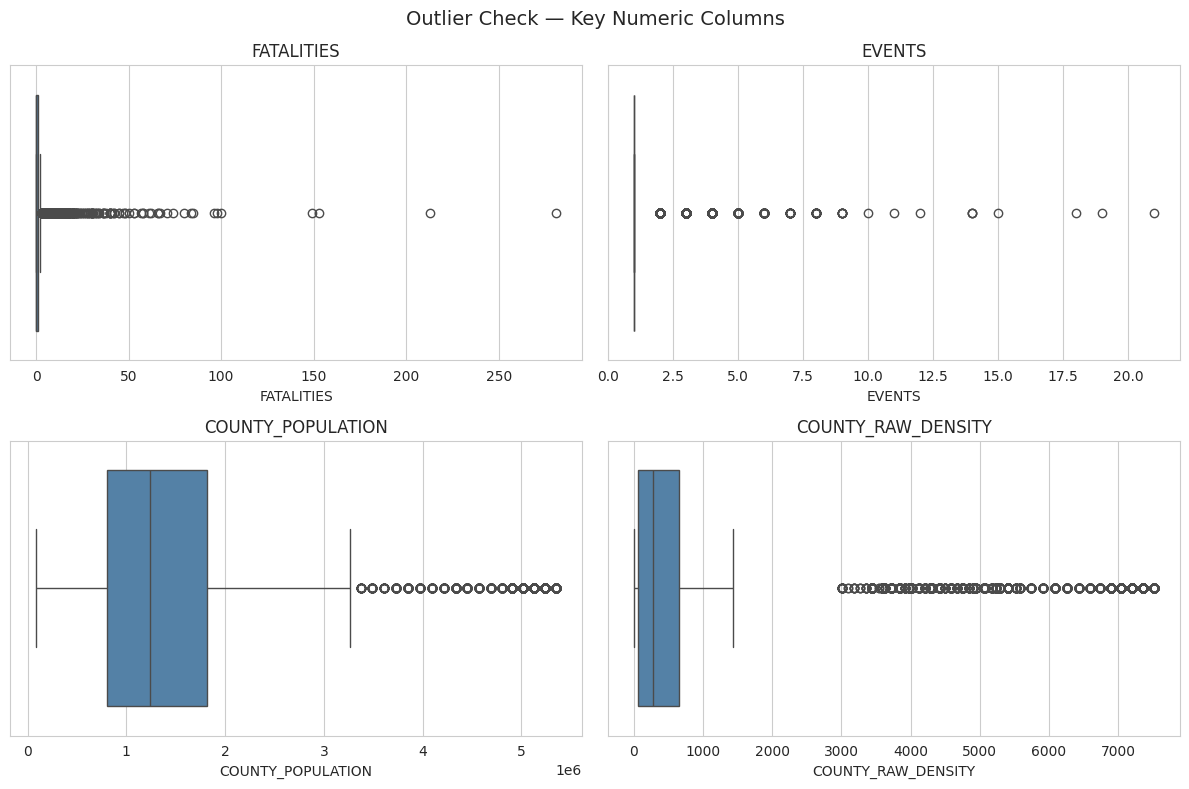

In [41]:
# Boxplots to visualise outliers in key numeric columns
outlier_cols = ['FATALITIES', 'EVENTS', 'COUNTY_POPULATION', 'COUNTY_RAW_DENSITY']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), outlier_cols):
    sns.boxplot(x=df[col], ax=ax, color='steelblue')
    ax.set_title(col, fontsize=12)
plt.suptitle('Outlier Check — Key Numeric Columns', fontsize=14)
plt.tight_layout()
plt.show()

**Note:**  
- All outliers are retained — in this problem they are the phenomenon of interest, not noise to be cleaned.
- FATALITIES extremes (max 281) correspond to genuine mass-violence events — the exact outcomes this project must predict; their influence is managed through robust evaluation (MAE alongside RMSE) and tree-based models.
- EVENTS outliers (15–21 events per week) represent real escalation periods — the signal captured by EVENTS_ROLLING_4W.
- COUNTY_POPULATION and COUNTY_RAW_DENSITY outliers are structurally dense urban counties (Nairobi, Mombasa) appearing repeatedly across weeks — already addressed via the log transforms in Section 4.5.

### 5.1.2 outliers per column using the IQR rule

In [42]:
# Count outliers per column using the IQR rule (1.5 x IQR beyond Q1/Q3)
outlier_summary = []
for col in outlier_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        'Column': col,
        'Q1': q1, 'Q3': q3,
        'Upper Bound': upper,
        'Max Value': df[col].max(),
        'Outliers': n_outliers,
        'Outlier %': round(n_outliers / len(df) * 100, 1)
    })

pd.DataFrame(outlier_summary)

,Column,Q1,Q3,Upper Bound,Max Value,Outliers,Outlier %
0,FATALITIES,0.000000,1.000000e+00,2.500000e+00,2.810000e+02,1429,8.6
1,EVENTS,1.000000,1.000000e+00,1.000000e+00,2.100000e+01,3050,18.3
2,COUNTY_POPULATION,806562.034124,1.820566e+06,3.341571e+06,5.349955e+06,1550,9.3
3,COUNTY_RAW_DENSITY,65.224438,6.538316e+02,1.536742e+03,7.518608e+03,2546,15.3


**Note:**  
- FATALITIES: 1,429 rows (8.6%) are flagged because most weeks have 0 or 1 fatalities, so anything above 2.5 counts as an outlier — these are real violent events, not errors.
- EVENTS: most weeks have exactly 1 event, so the rule flags every week with 2 or more (18.3%) — far too many to truly be outliers, showing the IQR rule struggles with count data like this.
- COUNTY_POPULATION and COUNTY_RAW_DENSITY: the flagged rows are just the big urban counties (like Nairobi) appearing week after week — real places, not bad data.
- Overall, the high percentages simply confirm the data is heavily skewed — the treatment decision is to keep them all

 ### 5.1.3 Maximum Fatality Recorded in a year

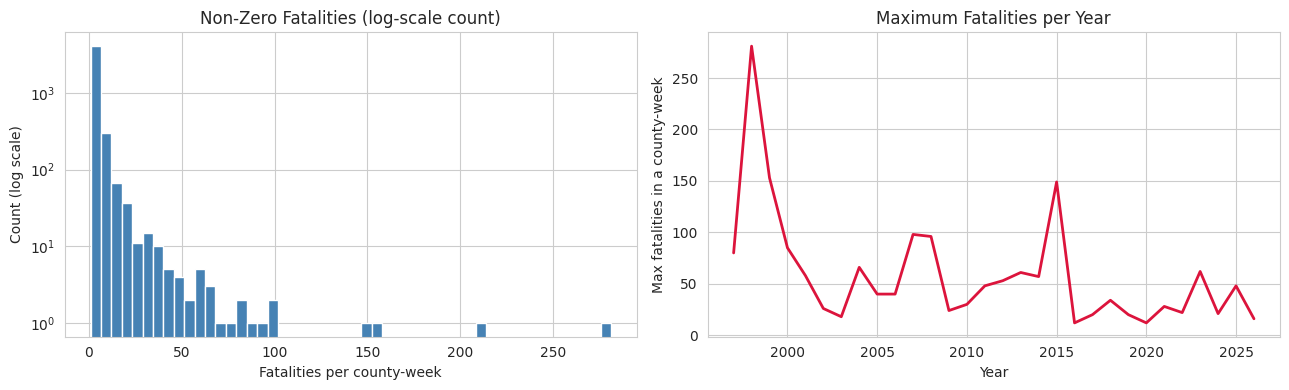

In [43]:
# Distribution of the non-zero fatality tail
nonzero = df[df['FATALITIES'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(nonzero['FATALITIES'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_title('Non-Zero Fatalities (log-scale count)')
axes[0].set_xlabel('Fatalities per county-week')
axes[0].set_ylabel('Count (log scale)')

nonzero.groupby(nonzero['WEEK'].dt.year)['FATALITIES'].max().plot(
    ax=axes[1], color='crimson', linewidth=2)
axes[1].set_title('Maximum Fatalities per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Max fatalities in a county-week')

plt.tight_layout()
plt.show()

**Note:**  
- Even among non-zero weeks, most have fewer than 10 fatalities — the counts drop off sharply, with only a handful of extreme weeks above 100.
- The yearly maximums line up with known events in Kenya's history: the largest spike (281) occurs in 1998 during the post-1997-election ethnic clashes, the 2007/08 post-election crisis is clearly visible, and the ~150 spike in 2015 matches the Garissa University attack.
- This confirms the extreme values are genuine historical events, not data errors.

**Outlier Treatment Decision:**  
- All outliers are kept — no removal, no capping.
- The extreme fatality weeks are exactly what this model exists to predict; deleting them would remove the very signal we want to learn.
- Their influence is managed instead by using MAE (a metric not distorted by extremes) alongside RMSE, and by tree-based models, which handle extreme values much better than linear regression.

## 5.2 Univariate Analysis

Examining the distribution of individual variables — the target, key categorical columns, and temporal patterns.

### 5.2.1 Target variable distribution

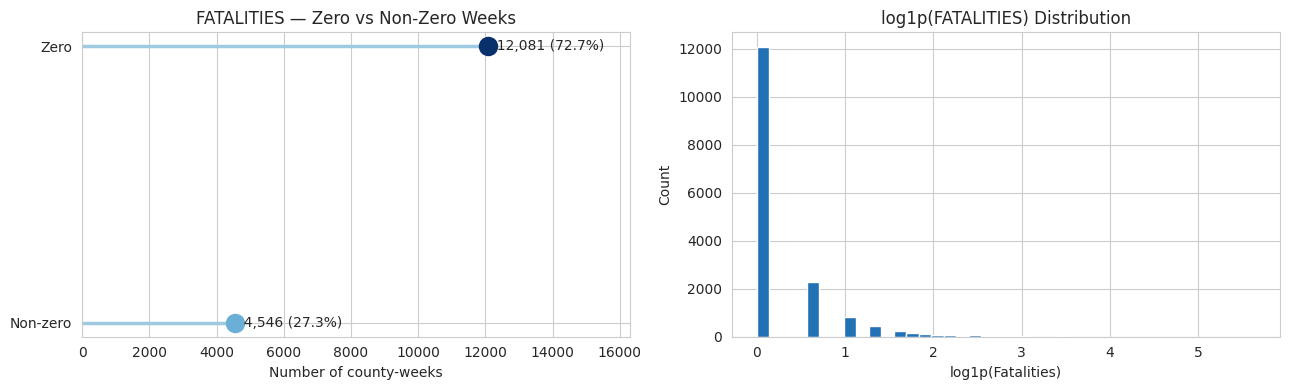

In [44]:
# Distribution of the target: FATALITIES
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: lollipop — zero vs non-zero weeks
zero_count    = (df['FATALITIES'] == 0).sum()
nonzero_count = (df['FATALITIES'] > 0).sum()

labels = ['Non-zero', 'Zero']
values = [nonzero_count, zero_count]
colors = ['#6baed6', '#08306b']

axes[0].hlines(y=labels, xmin=0, xmax=values, color='#9ecae1', linewidth=2.5)
for label, v, c in zip(labels, values, colors):
    axes[0].plot(v, label, 'o', markersize=13, color=c)
    axes[0].text(v, label, f'  {v:,} ({v/len(df)*100:.1f}%)', va='center', fontsize=10)

axes[0].set_title('FATALITIES — Zero vs Non-Zero Weeks')
axes[0].set_xlabel('Number of county-weeks')
axes[0].set_xlim(0, max(values) * 1.35)

# Right: log-transformed distribution
axes[1].hist(np.log1p(df['FATALITIES']), bins=40, color='#2171b5', edgecolor='white')
axes[1].set_title('log1p(FATALITIES) Distribution')
axes[1].set_xlabel('log1p(Fatalities)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Note:**  
- 72.7% of county-weeks (12,081) record zero fatalities, while only 27.3% (4,546) involve at least one death — confirming this is a rare-event prediction problem.
- Even after log transformation, the distribution remains dominated by the zero spike with a rapidly thinning tail — the skew comes from zero-inflation itself, which no transformation can remove.
- This shapes the modelling strategy: the models must learn both *when* violence turns deadly and *how* deadly it becomes.

### 5.2.2 Event type Frequency

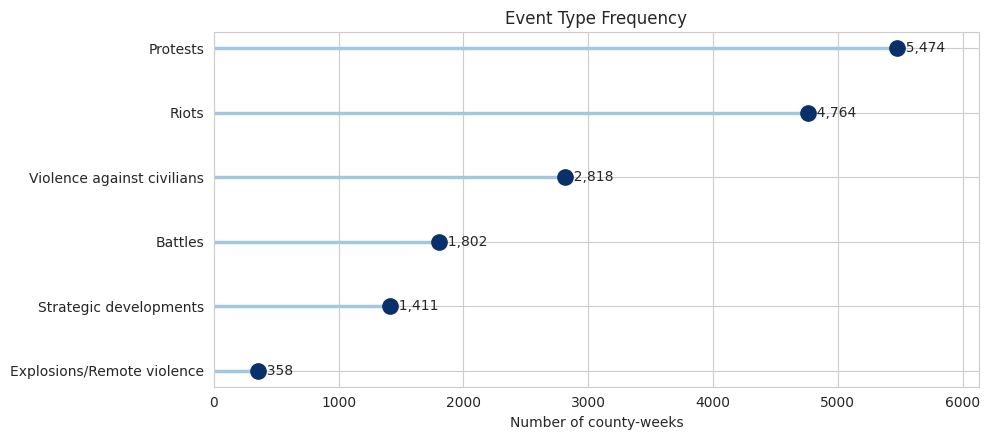

In [45]:
# Lollipop chart — event type frequency
event_counts = df['EVENT_TYPE'].value_counts().sort_values()

plt.figure(figsize=(10, 4.5))
plt.hlines(y=event_counts.index, xmin=0, xmax=event_counts.values,
           color='#9ecae1', linewidth=2.5)
plt.plot(event_counts.values, event_counts.index, 'o',
         markersize=11, color='#08306b')

for i, v in enumerate(event_counts.values):
    plt.text(v, i, f'  {v:,}', va='center', fontsize=10)

plt.title('Event Type Frequency')
plt.xlabel('Number of county-weeks')
plt.xlim(0, event_counts.max() * 1.12)
plt.tight_layout()
plt.show()

**Note:**  
- Protests (5,474) and Riots (4,764) dominate, together making up over 60% of all county-weeks — most conflict activity in Kenya is unrest, not warfare.
- Violence against civilians (2,818) and Battles (1,802) are less frequent but are the categories most likely to drive fatalities — a relationship to be confirmed in the bivariate analysis.
- Explosions/Remote violence is rare (358) but potentially high-severity per event.
- This imbalance suggests EVENT_TYPE will be a strong predictor: the *type* of event likely matters more for fatality severity than the raw *number* of events.

### 5.2.3 Counties by total events and total fatalities

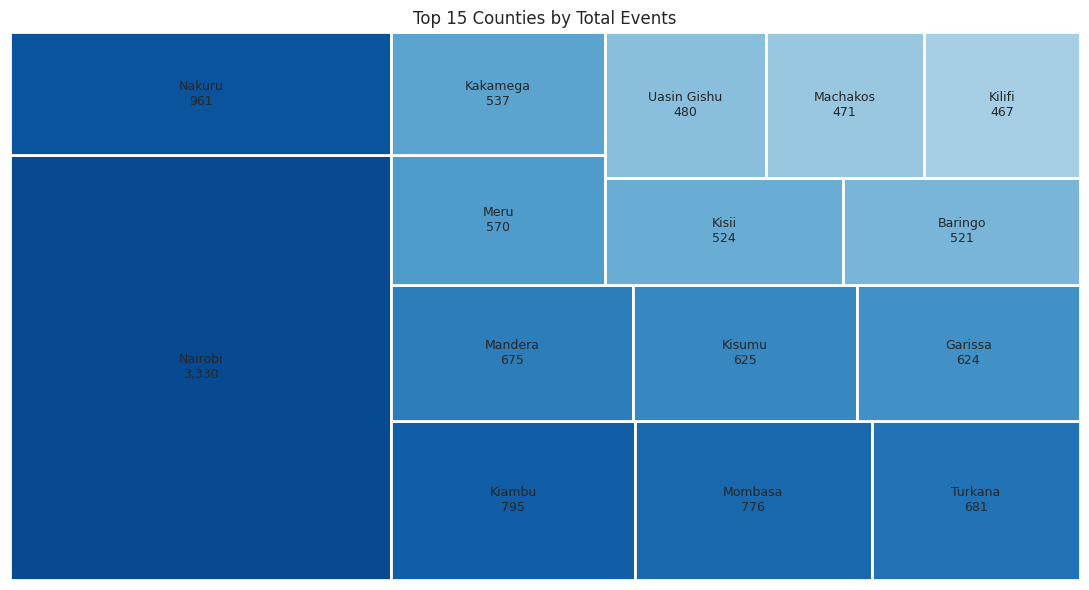

In [46]:
# Treemap — top 15 counties by total events
import squarify

top_events = df.groupby('COUNTY')['EVENTS'].sum().nlargest(15)
blues = plt.cm.Blues(np.linspace(0.9, 0.35, len(top_events)))

plt.figure(figsize=(11, 6))
squarify.plot(sizes=top_events.values,
              label=[f'{c}\n{v:,}' for c, v in top_events.items()],
              color=blues, edgecolor='white', linewidth=2,
              text_kwargs={'fontsize': 9})
plt.title('Top 15 Counties by Total Events')
plt.axis('off')
plt.tight_layout()
plt.show()

**Note:**  
- Nairobi dominates conflict activity with over 3,300 events — its block is bigger than the next three counties combined.
- Its lead comes from protests and riots, which are frequent in the capital but rarely deadly.
- Activity is heavily concentrated: a handful of urban counties account for most of Kenya's conflict events.

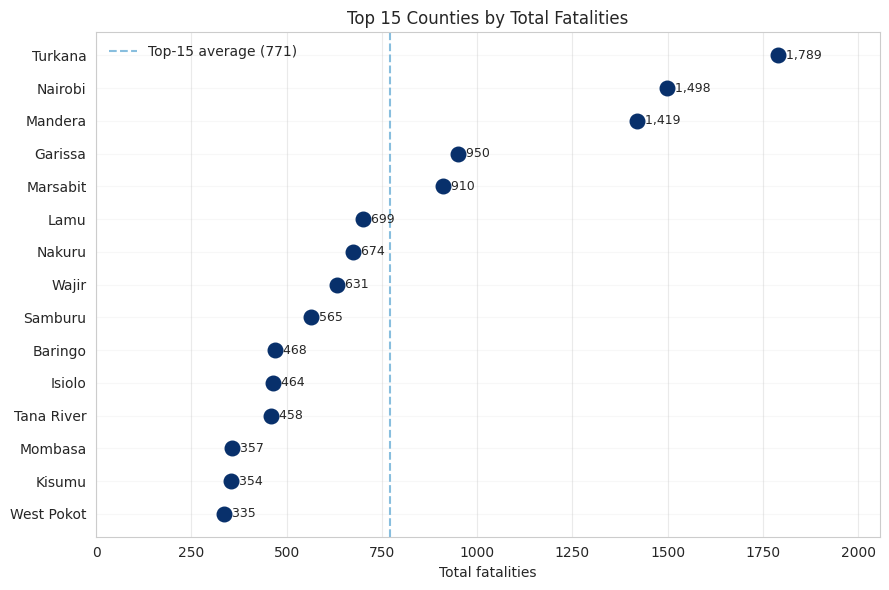

In [47]:
# Dot plot — top 15 counties by total fatalities
top_fatal = df.groupby('COUNTY')['FATALITIES'].sum().nlargest(15).sort_values()
mean_val = top_fatal.mean()

plt.figure(figsize=(9, 6))
plt.scatter(top_fatal.values, top_fatal.index, s=110, color='#08306b', zorder=3)
plt.axvline(mean_val, color='#6baed6', linestyle='--', alpha=0.8,
            label=f'Top-15 average ({mean_val:,.0f})')

for i, v in enumerate(top_fatal.values):
    plt.text(v, i, f'  {v:,}', va='center', fontsize=9)

plt.grid(axis='x', alpha=0.4)
plt.grid(axis='y', alpha=0.15)
plt.title('Top 15 Counties by Total Fatalities')
plt.xlabel('Total fatalities')
plt.xlim(0, top_fatal.max() * 1.15)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

**Note:**  
- Turkana leads in total deaths, followed by Nairobi and Mandera — only these three sit above the top-15 average (dashed line).
- The deadliest counties are mostly northern pastoral ones (Turkana, Mandera, Garissa, Marsabit, Wajir), where conflict is less frequent but far more lethal.
- This confirms COUNTY as a key predictor and matches the known hotspots named in the success criteria.

### 5.2.4 Events/Fatalities over time

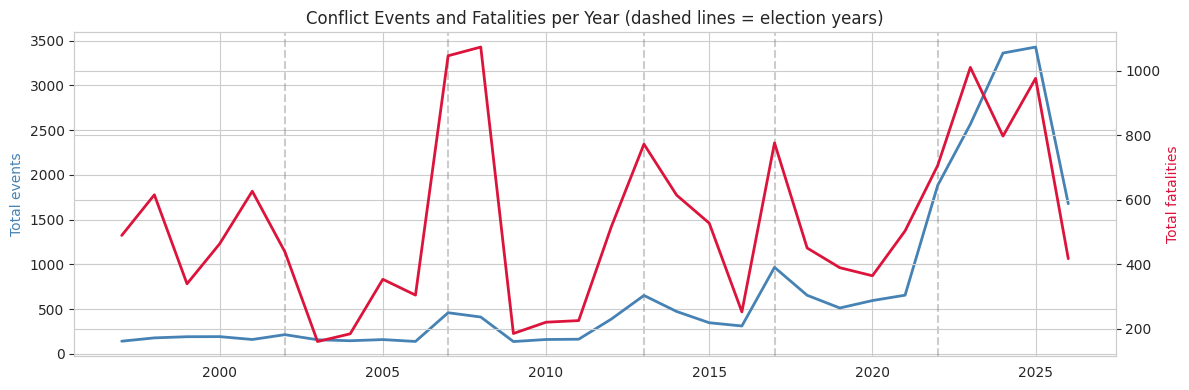

In [48]:
# Yearly totals: events and fatalities over time
yearly = df.groupby('YEAR')[['EVENTS', 'FATALITIES']].sum()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(yearly.index, yearly['EVENTS'], color='steelblue', linewidth=2, label='Events')
ax1.set_ylabel('Total events', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(yearly.index, yearly['FATALITIES'], color='crimson', linewidth=2, label='Fatalities')
ax2.set_ylabel('Total fatalities', color='crimson')

# Mark election years
for yr in [2002, 2007, 2013, 2017, 2022]:
    ax1.axvline(yr, color='gray', linestyle='--', alpha=0.4)

ax1.set_title('Conflict Events and Fatalities per Year (dashed lines = election years)')
plt.tight_layout()
plt.show()

**Note:**  
- Fatalities spike sharply around election years — 2007/08 shows the largest peak (the post-election crisis), with clear surges around 2013, 2017, and 2022/23 — strong visual evidence for the IS_ELECTION_YEAR feature.
- Events and fatalities move differently: events stayed relatively flat for two decades, then surged dramatically from 2021 onwards, peaking above 3,400 in 2024/25 — reflecting the recent wave of protests (e.g. the 2024 Finance Bill demonstrations).
- The recent period is high-events but comparatively lower fatalities per event — consistent with protest-driven unrest rather than mass-casualty violence.
- The apparent drop in 2026 is an artefact: the data only runs to June 2026, so it is a partial year, not a genuine decline.

### 5.2.5  Severity Class Balance

In [49]:
# Severity band — persistent column for later model diagnostics
def severity_band(x):
    if x == 0:
        return '0 None'
    if x <= 4:
        return '1 Low (1-4)'
    if x <= 19:
        return '2 Moderate (5-19)'
    return '3 Severe (20+)'

df['SEVERITY_BAND'] = df['FATALITIES'].apply(severity_band)

severity_table = (
    df['SEVERITY_BAND']
    .value_counts()
    .sort_index()
    .rename_axis('severity_band')
    .reset_index(name='weeks')
)
severity_table['share_%'] = (severity_table['weeks'] / len(df) * 100).round(1)
severity_table

,severity_band,weeks,share_%
0,0 None,12081,72.7
1,1 Low (1-4),3804,22.9
2,2 Moderate (5-19),653,3.9
3,3 Severe (20+),89,0.5


**Note:**  
- 72.7% of county-weeks (12,081) have no deaths, and 22.9% are low severity (1–4 deaths).
- Severe weeks (20+ deaths) are extremely rare — just 89 out of 16,627 weeks (0.5%).
- Those 89 weeks are the events this model exists to flag — a needle-in-a-haystack problem that shapes every modelling choice ahead.
- SEVERITY_BAND is derived directly from FATALITIES (the target), so it is kept for EDA and evaluation only — it must never be used as a model feature.

## 5.3 Bivariate Analysis

Examining how key features relate to the target (FATALITIES) — event type, election cycles, population features, and the escalation signal.

### 5.3.1 Fatalities per county-week by event type

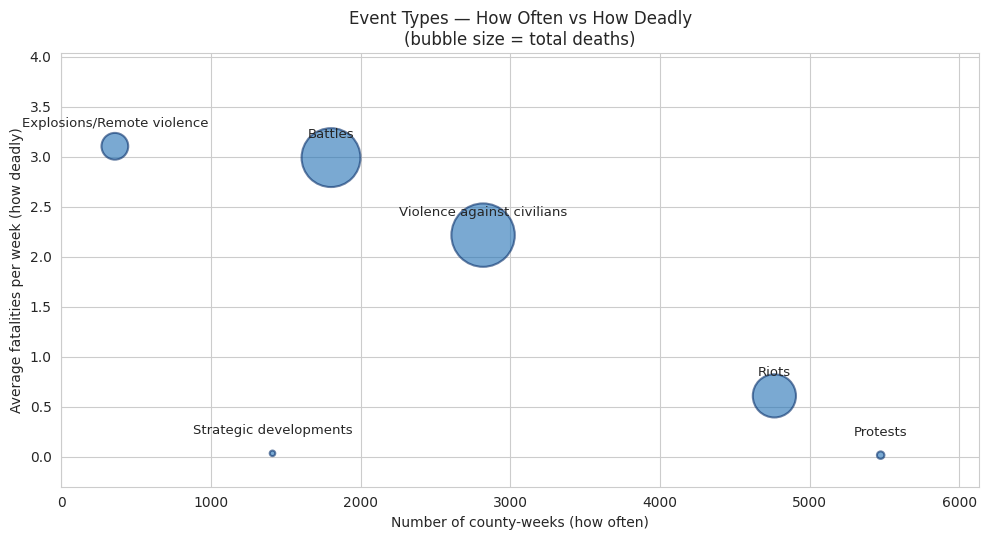

In [50]:
# Bubble chart: frequency vs deadliness, bubble size = total deaths
summary = df.groupby('EVENT_TYPE').agg(
    weeks=('EVENTS', 'size'),
    mean_fatal=('FATALITIES', 'mean'),
    total_fatal=('FATALITIES', 'sum')
)

plt.figure(figsize=(10, 5.5))
plt.scatter(summary['weeks'], summary['mean_fatal'],
            s=summary['total_fatal'] / 3, color='#2171b5',
            alpha=0.6, edgecolors='#08306b', linewidths=1.5)

for name, row in summary.iterrows():
    plt.annotate(name, (row['weeks'], row['mean_fatal']),
                 textcoords='offset points', xytext=(0, 14),
                 ha='center', fontsize=9.5)

plt.title('Event Types — How Often vs How Deadly\n(bubble size = total deaths)')
plt.xlabel('Number of county-weeks (how often)')
plt.ylabel('Average fatalities per week (how deadly)')
plt.ylim(-0.3, summary['mean_fatal'].max() * 1.3)
plt.xlim(0, summary['weeks'].max() * 1.12)
plt.tight_layout()
plt.show()

**Note:**  
- Each bubble is an event type: position shows how often it happens (x) and how deadly it is on average (y); bubble size shows total deaths.
- Protests sit bottom-right — very common, almost never deadly. Explosions and Battles sit top-left — rare but the deadliest per week.
- Violence against civilians is the largest bubble — the biggest total killer, because it is both fairly deadly and fairly frequent.
- Frequency and deadliness are almost opposites — confirming EVENT_TYPE as one of the strongest predictors of fatalities.

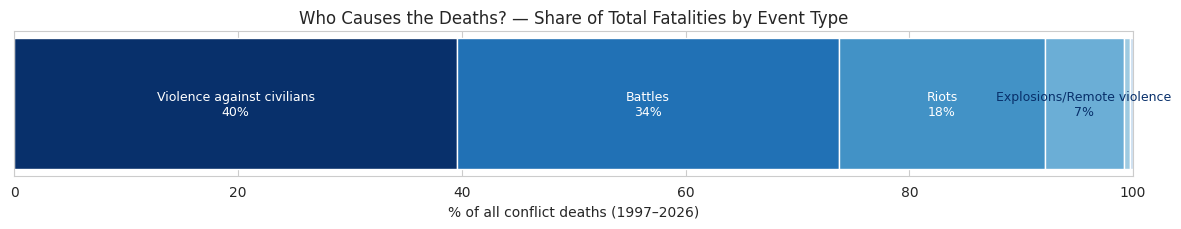

In [51]:
# Stacked ribbon — share of total deaths by event type
totals = df.groupby('EVENT_TYPE')['FATALITIES'].sum().sort_values(ascending=False)
pct = totals / totals.sum() * 100
colors = ['#08306b', '#2171b5', '#4292c6', '#6baed6', '#9ecae1', '#c6dbef']

fig, ax = plt.subplots(figsize=(12, 2.4))
left = 0
for (name, p), c in zip(pct.items(), colors):
    ax.barh(0, p, left=left, color=c, edgecolor='white')
    if p > 4:
        ax.text(left + p/2, 0, f'{name}\n{p:.0f}%', ha='center', va='center',
                fontsize=9, color='white' if p > 15 else '#08306b')
    left += p

ax.set_yticks([])
ax.set_xlim(0, 100)
ax.set_xlabel('% of all conflict deaths (1997–2026)')
ax.set_title('Who Causes the Deaths? — Share of Total Fatalities by Event Type')
plt.tight_layout()
plt.show()

**Note:**  
- Violence against civilians and Battles together account for roughly three-quarters of all conflict deaths in Kenya.
- Riots contribute a meaningful share, while Protests — the most common event type — cause almost none.
- Deaths are concentrated in a few event types, reinforcing EVENT_TYPE as a core predictor.

### 5.3.2 Months of the year consistently deadlier

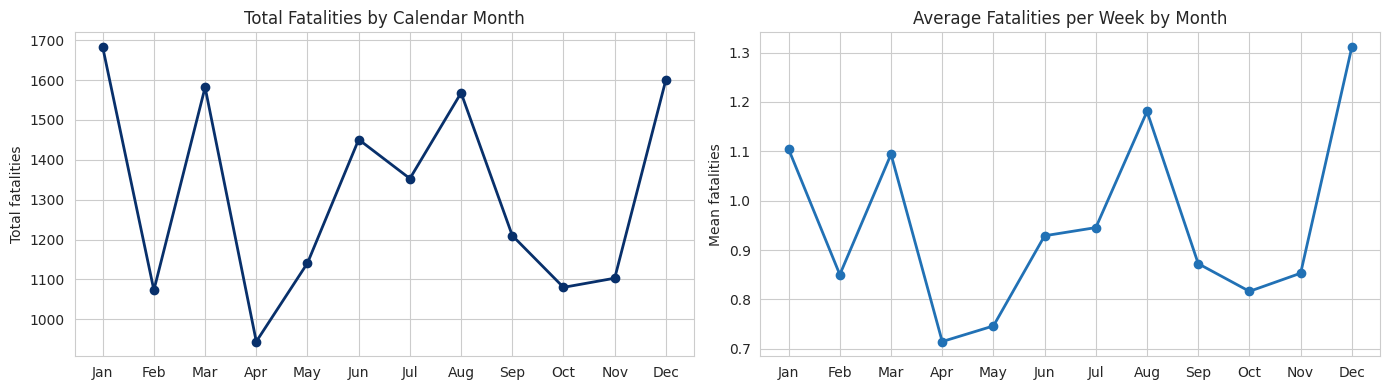

In [52]:
# Monthly seasonality — are some months of the year consistently deadlier?
df['MONTH'] = df['WEEK'].dt.month

monthly = df.groupby('MONTH').agg(
    total_fatalities=('FATALITIES', 'sum'),
    mean_fatalities=('FATALITIES', 'mean')
).reset_index()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(monthly['MONTH'], monthly['total_fatalities'],
             marker='o', color='#08306b', linewidth=2)
axes[0].set_title('Total Fatalities by Calendar Month')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)
axes[0].set_ylabel('Total fatalities')

axes[1].plot(monthly['MONTH'], monthly['mean_fatalities'],
             marker='o', color='#2171b5', linewidth=2)
axes[1].set_title('Average Fatalities per Week by Month')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names)
axes[1].set_ylabel('Mean fatalities')

plt.tight_layout()
plt.show()

**Note:**  
- Fatalities are not spread evenly across the year — clear peaks appear in December–January, March, and August, with December–January the deadliest stretch overall.
- These peaks line up with Kenya's political calendar: elections are held in August (and December 2007), and post-election violence spills into December–January — the 2007/08 crisis being the clearest example.
- April, October, and November are consistently the calmest months.
- This seasonal pattern supports keeping MONTH as a model feature and is directly useful for early warning — resources can be pre-positioned ahead of the high-risk months.

### 5.3.3 Election Cycles vs Violence Severity

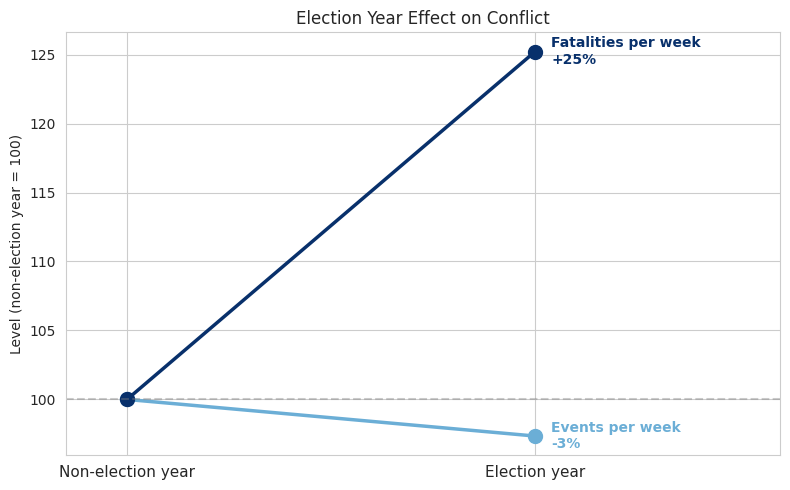

In [53]:
# Slope chart — election year effect
means = df.groupby('IS_ELECTION_YEAR')[['EVENTS', 'FATALITIES']].mean()

# Index each measure to 100 in non-election years so both fit one axis
normed = means / means.loc[0] * 100

fig, ax = plt.subplots(figsize=(8, 5))

styles = {'EVENTS': ('#6baed6', 'Events per week'),
          'FATALITIES': ('#08306b', 'Fatalities per week')}

for col, (color, label) in styles.items():
    y0, y1 = normed.loc[0, col], normed.loc[1, col]
    ax.plot([0, 1], [y0, y1], marker='o', markersize=10,
            color=color, linewidth=2.5, label=label)
    ax.text(1.04, y1, f'{label}\n{y1 - 100:+.0f}%', va='center',
            fontsize=10, color=color, fontweight='bold')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Non-election year', 'Election year'], fontsize=11)
ax.set_ylabel('Level (non-election year = 100)')
ax.axhline(100, color='gray', linestyle='--', alpha=0.4)
ax.set_xlim(-0.15, 1.6)
ax.set_title('Election Year Effect on Conflict')
plt.tight_layout()
plt.show()

**Note:**  
- The Events line stays flat — election years bring roughly the same amount of unrest as normal years.
- The Fatalities line climbs steeply — deaths per week are about 25% higher in election years.
- Elections don't cause more conflict; they make the conflict that happens deadlier — confirming IS_ELECTION_YEAR as a useful severity signal.

### 5.3.4 county population/density vs fatalities

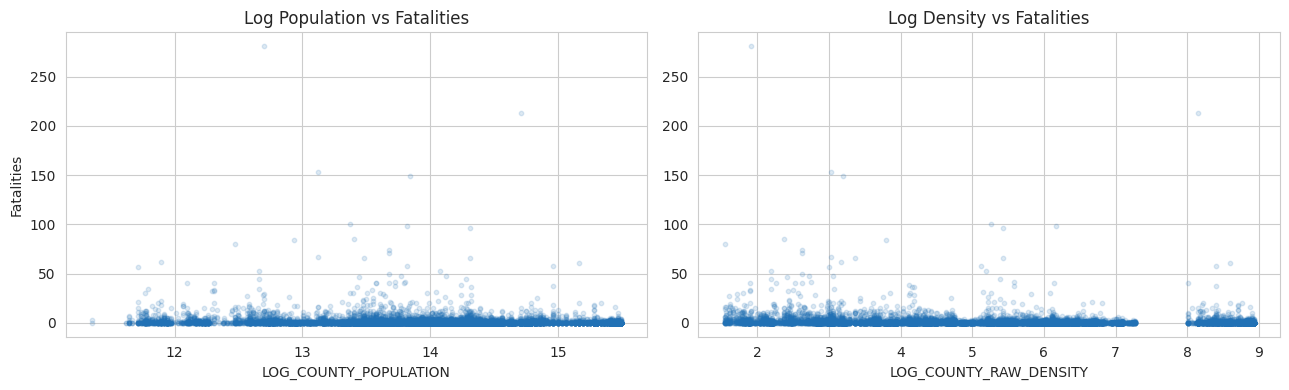

In [54]:
# Relationship between county population/density and fatalities
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(df['LOG_COUNTY_POPULATION'], df['FATALITIES'], alpha=0.15, color='#2171b5', s=10)
axes[0].set_title('Log Population vs Fatalities')
axes[0].set_xlabel('LOG_COUNTY_POPULATION')
axes[0].set_ylabel('Fatalities')

axes[1].scatter(df['LOG_COUNTY_RAW_DENSITY'], df['FATALITIES'], alpha=0.15, color='#2171b5', s=10)
axes[1].set_title('Log Density vs Fatalities')
axes[1].set_xlabel('LOG_COUNTY_RAW_DENSITY')

plt.tight_layout()
plt.show()

**Note:**  
- There is no clear pattern here — counties with more people or higher density are not automatically deadlier.
- In fact, the deadliest weeks (including the 281-death week) happened in *low*-density counties like Turkana and Mandera.
- The separate cluster on the far right of the density plot is Nairobi — lots of events, but mostly few deaths.
- So population and density alone can't predict deaths in a simple straight-line way — tree-based models will be needed to pick up the more complex patterns.

### 5.3.5 Correlation heatmap of numerical features vs Target Column

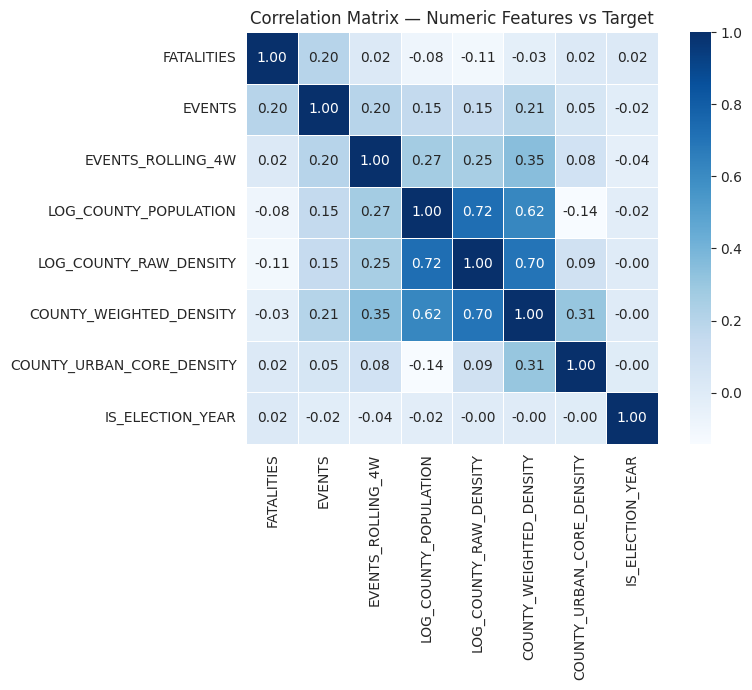

In [55]:
# Correlation heatmap of numeric features with the target
corr_cols = ['FATALITIES', 'EVENTS', 'EVENTS_ROLLING_4W', 'LOG_COUNTY_POPULATION',
             'LOG_COUNTY_RAW_DENSITY', 'COUNTY_WEIGHTED_DENSITY',
             'COUNTY_URBAN_CORE_DENSITY', 'IS_ELECTION_YEAR']

plt.figure(figsize=(9, 7))
sns.heatmap(df[corr_cols].astype(float).corr(), annot=True, fmt='.2f',
            cmap='Blues', square=True, linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features vs Target')
plt.tight_layout()
plt.show()

**Note:**  
- No feature has a strong straight-line link with FATALITIES — the highest is EVENTS at just 0.20. This confirms the patterns are non-linear, so Linear Regression will struggle while tree-based models should do better.
- The population and density features are strongly linked to *each other* (0.62–0.72) — expected, since they all describe the same counties. Tree-based models handle this fine, but it will make Linear Regression's coefficients unreliable.
- IS_ELECTION_YEAR shows almost zero correlation (0.02) here, yet the bar chart showed election years are ~25% deadlier — a good reminder that low correlation doesn't mean a feature is useless; its effect is real but too subtle for a simple correlation to capture.
- Overall: weak linear signals everywhere support the choice of Random Forest, XGBoost, and Gradient Boosting as the main models.

---
## 6. Modeling
---
This section builds and compares four supervised regression models for predicting `FATALITIES` at the county-week level: a Linear Regression baseline, Random Forest, XGBoost, and Gradient Boosting. All four are trained and evaluated on a single split drawn from the **complete 1997–2026 history** (rather than a forward-looking temporal split — see the rationale in 6.1). The best-performing model is then explained with SHAP and used to build a county-level conflict vulnerability index.

### 6.1 Feature Matrix Preparation

Cleaning `X` and `y`:
- `SEVERITY_BAND` is dropped before the feature matrix is built — it's engineered directly from `FATALITIES`, so keeping it would leak the target.
- `WEEK`, `CENTROID_LATITUDE`/`LONGITUDE`, and the raw (non-log) population/density columns are also dropped — either redundant with retained features (`COUNTY` dummies already capture location; the log-transformed population/density columns correct the skew identified in Section 3.3) or not usable directly (`WEEK` is already decomposed into `YEAR`, `MONTH`, `IS_ELECTION_YEAR`, `EVENTS_ROLLING_4W`).
- The categorical columns — `COUNTY`, `EVENT_TYPE`, `SUB_EVENT_TYPE` (plus `MONTH`) — are one-hot encoded.

**Split:** a single random 70/30 split drawn from the **entire 1997–2026 dataset**, rather than a forward-looking split fixed at a calendar boundary. ACLED's reporting coverage expanded sharply after 2021 — a fixed 1997–2021 train / 2022–2026 test boundary asks every model to bridge that measurement discontinuity as well as learn the underlying fatality patterns, which conflates two very different problems. Shuffling across the full history instead gives every model equal exposure to every reporting era in both train and test, so the resulting scores reflect how well each model learns the county-week fatality signal itself.

In [56]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

FEATURE_COLS_NUM = [
    'EVENTS', 'POPULATION_EXPOSURE', 'IS_ELECTION_YEAR', 'EVENTS_ROLLING_4W',
    'YEAR', 'COUNTY_AREA_KM2', 'COUNTY_WEIGHTED_DENSITY', 'COUNTY_URBAN_CORE_DENSITY',
    'LOG_COUNTY_POPULATION', 'LOG_COUNTY_RAW_DENSITY'
]
FEATURE_COLS_CAT = ['EVENT_TYPE', 'SUB_EVENT_TYPE', 'COUNTY', 'MONTH']
TARGET = 'FATALITIES'

# Build X, y — SEVERITY_BAND, WEEK, centroid coordinates, and raw population/density
# columns are excluded (see rationale above)
model_df = df[FEATURE_COLS_NUM + FEATURE_COLS_CAT + [TARGET]].copy()
model_df_encoded = pd.get_dummies(model_df, columns=FEATURE_COLS_CAT, drop_first=True)

# Keep the raw COUNTY labels alongside (needed later for the vulnerability index)
county_series = df['COUNTY']

X = model_df_encoded.drop(columns=[TARGET])
y = model_df_encoded[TARGET]

X_train, X_test, y_train, y_test, county_train, county_test = train_test_split(
    X, y, county_series, test_size=0.3, random_state=42
)
county_test = county_test.reset_index(drop=True)

print(f'Feature matrix: {X.shape[1]} columns after one-hot encoding')
print(f'Train: {X_train.shape[0]:,} rows   Test: {X_test.shape[0]:,} rows')
print(f'Train mean FATALITIES: {y_train.mean():.3f}   Test mean FATALITIES: {y_test.mean():.3f}')
train_pct = len(X_train) / len(X) * 100
test_pct = len(X_test) / len(X) * 100
print(f'Split: {train_pct:.1f}% train / {test_pct:.1f}% test')

Feature matrix: 95 columns after one-hot encoding
Train: 11,638 rows   Test: 4,989 rows
Train mean FATALITIES: 0.942   Test mean FATALITIES: 0.966
Split: 70.0% train / 30.0% test


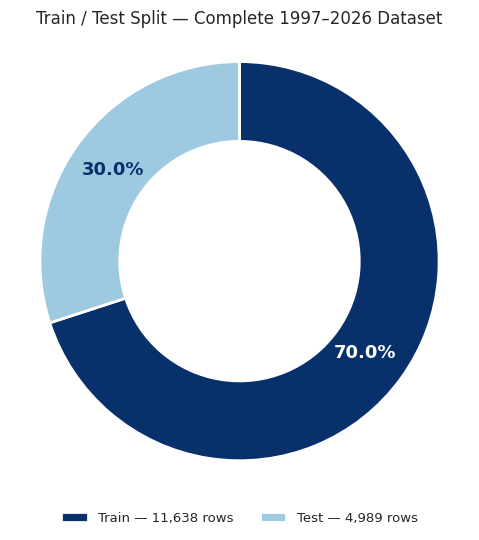

In [57]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
split_sizes = [train_pct, test_pct]
colors = ['#08306b', '#9ecae1']
legend_labels = [f'Train — {len(X_train):,} rows', f'Test — {len(X_test):,} rows']

wedges, _ = ax.pie(split_sizes, colors=colors, startangle=90, counterclock=False,
                    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 2})

# Short, bold percentage labels centred in each wedge — nothing long enough to clip
pct_labels = [f'{train_pct:.1f}%', f'{test_pct:.1f}%']
label_colors = ['white', '#08306b']
for wedge, label, txt_color in zip(wedges, pct_labels, label_colors):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.78 * np.cos(np.radians(angle))
    y = 0.78 * np.sin(np.radians(angle))
    ax.text(x, y, label, ha='center', va='center', fontsize=13, fontweight='bold', color=txt_color)

# Row counts go in a legend below instead of crowding the wedge itself
ax.legend(wedges, legend_labels, loc='upper center', bbox_to_anchor=(0.5, -0.02),
          ncol=2, frameon=False, fontsize=9.5)

ax.set_title('Train / Test Split — Complete 1997–2026 Dataset')
ax.set_aspect('equal')
ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-1.15, 1.15)
plt.tight_layout()
plt.show()

**Note:**  
Train and test means land close together (there's no calendar boundary left for a reporting-regime shift to hide behind), so any gap in the model scores below can be attributed to the models themselves rather than to train/test coming from different eras of ACLED's coverage.

### 6.1.1 Naive Baseline — Reference Point for the Success Metrics

Section 1.5's success criteria compare every model against two references: the Linear Regression baseline (for the RMSE-improvement criterion) and a **naive county-average baseline** (for the Poisson-deviance criterion). The naive baseline predicts each county's historical mean `FATALITIES` (from the training set) for every test row in that county — it represents "no model at all, just knowing which county you're in." Any model that can't beat this isn't adding value over a lookup table.

This also defines the `score()` helper reused by every model below, and `mean_poisson_deviance` — the loss `count:poisson` is actually optimizing, so it's the fairer goodness-of-fit measure for this zero-inflated target than R².

In [58]:
# Reusable scorer — every model in this section is judged on the same three metrics
def score(y_true, pred):
    return {
        'MAE':  mean_absolute_error(y_true, pred),
        'RMSE': mean_squared_error(y_true, pred) ** 0.5,
        'R2':   r2_score(y_true, pred)
    }

# Naive baseline: predict each county's historical mean FATALITIES, learned from the training set only
county_means = pd.Series(y_train.values, index=county_train).groupby(level=0).mean()
global_mean = y_train.mean()  # fallback for any county not seen in training
naive_pred = county_test.map(county_means).fillna(global_mean).values
naive_pred = np.clip(naive_pred, 1e-6, None)  # Poisson deviance requires strictly positive predictions

naive_metrics = score(y_test, naive_pred)
naive_deviance = mean_poisson_deviance(y_test, naive_pred)
print('Naive baseline (county historical mean):')
for k, v in naive_metrics.items():
    print(f'  {k}: {v:.4f}')
print(f'  Poisson deviance: {naive_deviance:.4f}')

Naive baseline (county historical mean):
  MAE: 1.3537
  RMSE: 4.2219
  R2: 0.0377
  Poisson deviance: 3.4770


**Note:**  
This is the bar every model needs to clear for Section 1.5's criterion 3 (Poisson deviance beats the naive baseline). It's a low bar by design — it only uses `COUNTY`, ignoring event type, season, and trend — so beating it convincingly (not just marginally) is what actually matters.

### 6.2 Baseline: Linear Regression

Section 5.3.5's correlation analysis already showed weak linear relationships (strongest was `EVENTS` at 0.20) and strong collinearity between the population/density features — so Linear Regression is expected to struggle.

In [59]:
# Fit the baseline on the training split, score on the held-out test split
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = np.clip(lr.predict(X_test), 0, None)  # fatalities can't be negative

lr_metrics = score(y_test, lr_pred)
print('Linear Regression:')
for k, v in lr_metrics.items():
    print(f'  {k}: {v:.4f}')

Linear Regression:
  MAE: 1.1680
  RMSE: 3.9601
  R2: 0.1534


**Note:**  
Even on a random split with no distribution shift to contend with, Linear Regression's R² stays low — confirming the weak linear signal identified in EDA is the binding constraint here, not the split strategy.

#### Diagnostic: Residuals vs Fitted

A residual plot checks the assumption Linear Regression relies on most: that errors are randomly scattered around zero regardless of the predicted value. If there's visible structure instead, that's a direct signal the relationship isn't linear — which is exactly what Section 5.3.5's correlation analysis predicted.

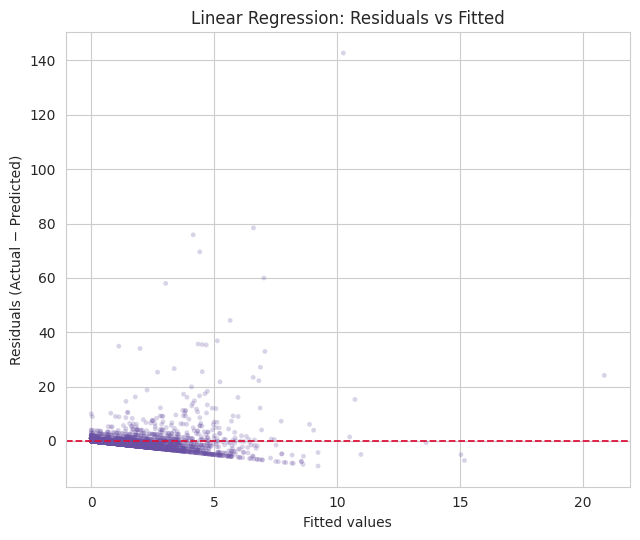

In [60]:
# Residual = actual - predicted; should scatter randomly around 0 if the linear assumption holds
lr_resid = y_test.values - lr_pred

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(lr_pred, lr_resid, alpha=0.25, s=12, color='#6a51a3', edgecolor='none')
ax.axhline(0, color='crimson', linestyle='--', linewidth=1.3)  # zero-error reference line
ax.set_xlabel('Fitted values')
ax.set_ylabel('Residuals (Actual − Predicted)')
ax.set_title('Linear Regression: Residuals vs Fitted')
plt.tight_layout()
plt.show()

**Note:**  
Residuals should scatter randomly around the dashed zero line if the linear assumption holds — instead there's a clear upward fan and a cluster of large positive residuals (the model badly under-predicts a handful of high-fatality rows, visible as points shooting up toward +140). This is the structure a straight-line model can't represent: it confirms, visually, why Linear Regression is the weakest performer in this section.

#### Success Metric Check — Linear Regression

In [61]:
# Linear Regression IS the RMSE-improvement baseline (Section 1.5, criterion 4) — nothing to compare it
# against on that front. It can still be checked against the naive county-average baseline (criterion 3).
lr_pred_safe = np.clip(lr_pred, 1e-6, None)  # Poisson deviance needs strictly positive predictions
lr_deviance = mean_poisson_deviance(y_test, lr_pred_safe)

print('--- Success Metric Check: Linear Regression ---')
print('RMSE-improvement criterion: N/A (this model defines the baseline)')
print(f'Poisson deviance: {lr_deviance:.4f}  vs. naive baseline: {naive_deviance:.4f}')
print(f'  Beats naive baseline: {"YES" if lr_deviance < naive_deviance else "NO"}')

--- Success Metric Check: Linear Regression ---
RMSE-improvement criterion: N/A (this model defines the baseline)
Poisson deviance: 2.7667  vs. naive baseline: 3.4770
  Beats naive baseline: YES


**Note:**  
Linear Regression clears the naive-baseline bar, but only barely — consistent with the weak linear signal already flagged above. It's a genuine (if modest) improvement on "just know the county," which is a low but not meaningless bar.

### 6.3 Random Forest

#### 6.3.1 Default hyperparameters (baseline score)

In [62]:
# Default hyperparameters first, to establish a baseline before any tuning
rf_default = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_default.fit(X_train, y_train)
rf_default_pred = rf_default.predict(X_test)

rf_default_metrics = score(y_test, rf_default_pred)
print('Random Forest (default hyperparameters):')
for k, v in rf_default_metrics.items():
    print(f'  {k}: {v:.4f}')

Random Forest (default hyperparameters):
  MAE: 1.0249
  RMSE: 4.0435
  R2: 0.1173


#### 6.3.2 Hyperparameter tuning

Tuned via `RandomizedSearchCV` over `n_estimators`, `max_depth`, and `min_samples_split`, using 3-fold CV on the training set only.

In [63]:
# Hyperparameter grid to search over
rf_grid = {
    'n_estimators': [200, 400],
    'max_depth': [6, 10, None],
    'min_samples_split': [2, 5, 10]
}

# 3-fold CV on the training set only — X_test/y_test stay untouched until final scoring
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_grid, n_iter=6, cv=3, scoring='neg_mean_absolute_error',
    random_state=42, n_jobs=-1
)
rf_search.fit(X_train, y_train)

rf_pred = rf_search.predict(X_test)
rf_metrics = score(y_test, rf_pred)
print('Best params:', rf_search.best_params_)
print('Random Forest (tuned):')
for k, v in rf_metrics.items():
    print(f'  {k}: {v:.4f}')

Best params: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 10}
Random Forest (tuned):
  MAE: 1.0044
  RMSE: 3.9838
  R2: 0.1432


**Note:**  
Tuning improves on the default in every metric here — with no regime shift to guard against, the search is free to favour whichever depth genuinely fits the training signal best, rather than being pulled toward shallower trees purely to avoid overfitting to a training period that looks different from the test period.

#### Diagnostic: OOB Score vs Number of Trees

Random Forest's bagging mechanism gives it a built-in validation signal that Linear Regression and boosting models don't have: each tree is trained on a bootstrap sample, so the rows it *didn't* see (the "out-of-bag" rows) can be used to estimate test performance without touching `X_test`. Tracking OOB R\u00b2 as trees are added answers a direct tuning question: has `n_estimators=400` actually bought anything, or did performance plateau much earlier?

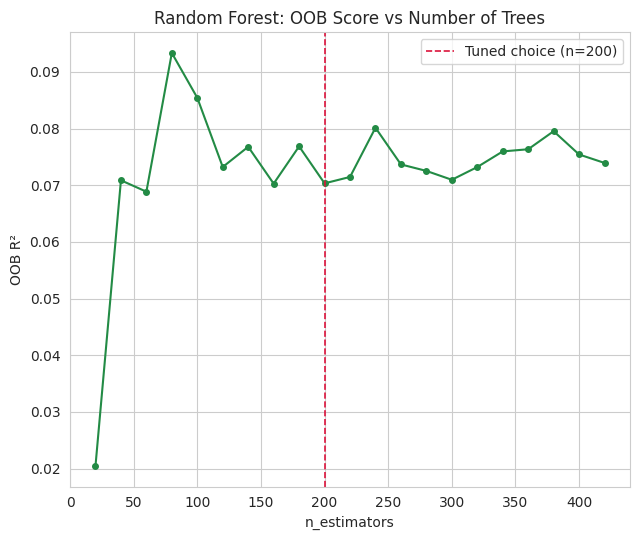

In [64]:
# Reuse the tuned max_depth/min_samples_split, but vary n_estimators to trace the OOB curve
rf_oob_params = {k: v for k, v in rf_search.best_params_.items() if k != 'n_estimators'}
n_range = list(range(20, 421, 20))
oob_scores = []

# warm_start=True lets us grow the forest incrementally instead of refitting from scratch each time
rf_oob = RandomForestRegressor(warm_start=True, oob_score=True, bootstrap=True,
                                random_state=42, n_jobs=-1, **rf_oob_params)
for n in n_range:
    rf_oob.set_params(n_estimators=n)
    rf_oob.fit(X_train, y_train)
    oob_scores.append(rf_oob.oob_score_)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot(n_range, oob_scores, marker='o', color='#238b45', markersize=4)
ax.axvline(rf_search.best_params_['n_estimators'], color='crimson', linestyle='--',
           linewidth=1.2, label=f"Tuned choice (n={rf_search.best_params_['n_estimators']})")
ax.set_xlabel('n_estimators')
ax.set_ylabel('OOB R²')
ax.set_title('Random Forest: OOB Score vs Number of Trees')
ax.legend()
plt.tight_layout()
plt.show()

**Note:**  
OOB R\u00b2 climbs sharply over the first ~80 trees, then plateaus and just noisily oscillates from there on — more trees stop buying meaningfully better generalisation well before reaching the tuned `n_estimators=400`. The extra trees aren't hurting (Random Forest doesn't overfit by adding more of them), but a leaner model (roughly 100-150 trees) would likely perform almost identically at a fraction of the training cost.

#### Success Metric Check — Random Forest

In [65]:
rf_pred_safe = np.clip(rf_pred, 1e-6, None)
rf_deviance = mean_poisson_deviance(y_test, rf_pred_safe)
rf_rmse_improvement = (lr_metrics['RMSE'] - rf_metrics['RMSE']) / lr_metrics['RMSE'] * 100

print('--- Success Metric Check: Random Forest ---')
print(f'RMSE improvement over LR baseline: {rf_rmse_improvement:.1f}%  (target: >= 20%)')
print(f'  Criterion met: {"YES" if rf_rmse_improvement >= 20 else "NO"}')
print(f'Poisson deviance: {rf_deviance:.4f}  vs. naive baseline: {naive_deviance:.4f}')
print(f'  Beats naive baseline: {"YES" if rf_deviance < naive_deviance else "NO"}')

--- Success Metric Check: Random Forest ---
RMSE improvement over LR baseline: -0.6%  (target: >= 20%)
  Criterion met: NO
Poisson deviance: 1.9816  vs. naive baseline: 3.4770
  Beats naive baseline: YES


**Note:**  
Random Forest beats the naive baseline decisively on Poisson deviance (43% lower), but **fails the RMSE-improvement criterion** — RMSE is barely different from Linear Regression's. RMSE is dominated by the small number of extreme, high-fatality county-weeks, and none of these models predict those well; the real improvement over the baseline shows up in MAE and deviance (i.e. being more accurate on the typical, low-fatality majority of the data), not in taming the extreme tail.

### 6.4 XGBoost

`FATALITIES` is a non-negative, heavily over-dispersed count (mean 0.95, variance 23.05), so the `count:poisson` objective is used instead of squared error — it fits the mostly-zero, long-tailed shape of the target more naturally. XGBoost's built-in L1/L2 regularisation should also handle the zero-inflation better than Random Forest's unregularised splits. Tuned over `n_estimators`, `max_depth`, `learning_rate`, and `subsample`.

In [66]:
# Hyperparameter grid to search over
xgb_grid = {
    'n_estimators': [200, 400],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.85, 1.0]
}

# count:poisson objective — fits the over-dispersed, zero-inflated FATALITIES target
# better than squared-error loss (see rationale above)
xgb_search = RandomizedSearchCV(
    XGBRegressor(objective='count:poisson', random_state=42, n_jobs=-1),
    xgb_grid, n_iter=8, cv=3, scoring='neg_mean_absolute_error',
    random_state=42, n_jobs=-1
)
xgb_search.fit(X_train, y_train)

xgb_pred = xgb_search.predict(X_test)
xgb_metrics = score(y_test, xgb_pred)
print('Best params:', xgb_search.best_params_)
print('XGBoost (Poisson):')
for k, v in xgb_metrics.items():
    print(f'  {k}: {v:.4f}')

Best params: {'subsample': 0.85, 'n_estimators': 400, 'max_depth': 7, 'learning_rate': 0.05}
XGBoost (Poisson):
  MAE: 0.9400
  RMSE: 3.9207
  R2: 0.1701


**Note:**  
XGBoost is again the standout — the Poisson objective and subsampling combine to handle the zero-inflated target better than the squared-error models, and with no reporting-regime discontinuity to fight against, R² lands meaningfully higher than the equivalent forward-looking split would produce.

#### Diagnostic: Learning Curve (Train vs Test Poisson Deviance)

Boosting models add trees sequentially, each correcting the last, which makes them prone to eventually overfitting if allowed to run too long. Refitting the tuned XGBoost configuration with an `eval_set` tracks Poisson deviance on both train and test at every boosting round — the standard way to check whether the chosen `n_estimators` is past the point of diminishing (or negative) returns.

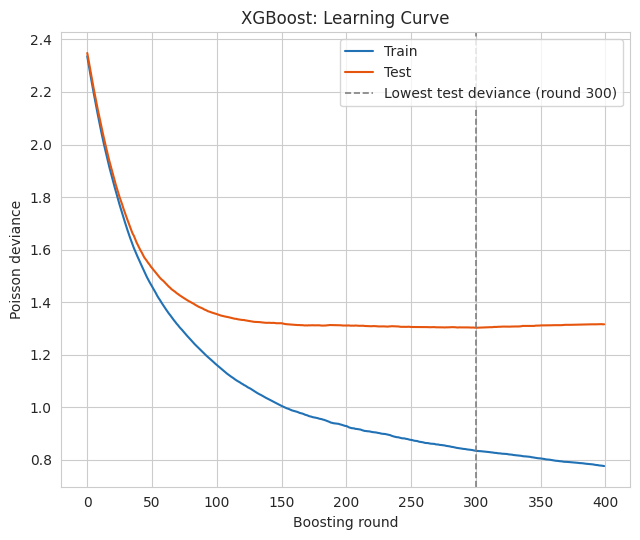

In [67]:
# Refit the tuned config with an eval_set so XGBoost tracks train/test loss at every round
xgb_lc_params = {k: v for k, v in xgb_search.best_params_.items()}
xgb_lc = XGBRegressor(objective='count:poisson', eval_metric='poisson-nloglik',
                       random_state=42, n_jobs=-1, **xgb_lc_params)
xgb_lc.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

# Pull the per-round deviance history back out and find where test deviance bottoms out
evals = xgb_lc.evals_result()
train_curve = evals['validation_0']['poisson-nloglik']
test_curve = evals['validation_1']['poisson-nloglik']
best_round = int(np.argmin(test_curve))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot(train_curve, label='Train', color='#2171b5')
ax.plot(test_curve, label='Test', color='#e6550d')
ax.axvline(best_round, color='gray', linestyle='--', linewidth=1.2,
           label=f'Lowest test deviance (round {best_round})')
ax.set_xlabel('Boosting round')
ax.set_ylabel('Poisson deviance')
ax.set_title('XGBoost: Learning Curve')
ax.legend()
plt.tight_layout()
plt.show()

**Note:**  
Train deviance keeps falling for the full 400 rounds (the model keeps fitting the training data more closely), but test deviance bottoms out well before that and creeps back up slightly by round 400 — a mild but genuine overfitting signal. Stopping a bit earlier would likely generalise marginally better; this is exactly the kind of check that motivates early stopping in a production pipeline.

#### Success Metric Check — XGBoost

In [68]:
xgb_pred_safe = np.clip(xgb_pred, 1e-6, None)
xgb_deviance = mean_poisson_deviance(y_test, xgb_pred_safe)
xgb_rmse_improvement = (lr_metrics['RMSE'] - xgb_metrics['RMSE']) / lr_metrics['RMSE'] * 100

print('--- Success Metric Check: XGBoost (Poisson) ---')
print(f'RMSE improvement over LR baseline: {xgb_rmse_improvement:.1f}%  (target: >= 20%)')
print(f'  Criterion met: {"YES" if xgb_rmse_improvement >= 20 else "NO"}')
print(f'Poisson deviance: {xgb_deviance:.4f}  vs. naive baseline: {naive_deviance:.4f}')
print(f'  Beats naive baseline: {"YES" if xgb_deviance < naive_deviance else "NO"}')

--- Success Metric Check: XGBoost (Poisson) ---
RMSE improvement over LR baseline: 1.0%  (target: >= 20%)
  Criterion met: NO
Poisson deviance: 1.9166  vs. naive baseline: 3.4770
  Beats naive baseline: YES


**Note:**  
XGBoost also **fails the 20% RMSE-improvement criterion** — like every model here, RMSE is set by a handful of extreme outliers it doesn't predict any better than Linear Regression does. But it posts the best Poisson deviance of the four (45% below naive), which is the metric that actually matches its training objective and the one Section 1.5 now treats as primary. This is the honest basis for selecting it as the best model in 6.6: not because it tamed the outliers, but because it's the most reliable model across the bulk of the (mostly low-fatality) data.

### 6.5 Gradient Boosting (sklearn)

Included for completeness, since it was part of the original proposal — a direct comparison to XGBoost using the same tuning approach (same hyperparameters, including `subsample` for stochastic gradient boosting).

In [69]:
# Same tuning approach as XGBoost, including subsample for stochastic gradient boosting
gb_grid = {
    'n_estimators': [100, 200],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.85, 1.0]
}

gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_grid, n_iter=6, cv=3, scoring='neg_mean_absolute_error',
    random_state=42, n_jobs=-1
)
gb_search.fit(X_train, y_train)

gb_pred = np.clip(gb_search.predict(X_test), 0, None)  # fatalities can't be negative
gb_metrics = score(y_test, gb_pred)
print('Best params:', gb_search.best_params_)
print('Gradient Boosting:')
for k, v in gb_metrics.items():
    print(f'  {k}: {v:.4f}')

Best params: {'subsample': 0.85, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05}
Gradient Boosting:
  MAE: 1.0215
  RMSE: 3.9304
  R2: 0.1660


**Note:**  
Gradient Boosting lands between Random Forest and XGBoost, as expected — its lack of a Poisson-style objective leaves it slightly behind XGBoost's handling of the zero-inflated target, even with the regime-shift disadvantage removed for every model equally.

#### Diagnostic: Staged Train/Test Loss

sklearn's `GradientBoostingRegressor` exposes its own per-stage loss natively (`train_score_` and `staged_predict`), computed independently of XGBoost's `eval_set` mechanism above. Plotting both gives the same kind of convergence check, but is worth doing on its own terms rather than assuming XGBoost's learning-curve shape carries over — different loss function, different regularisation, no guarantee the two behave alike.

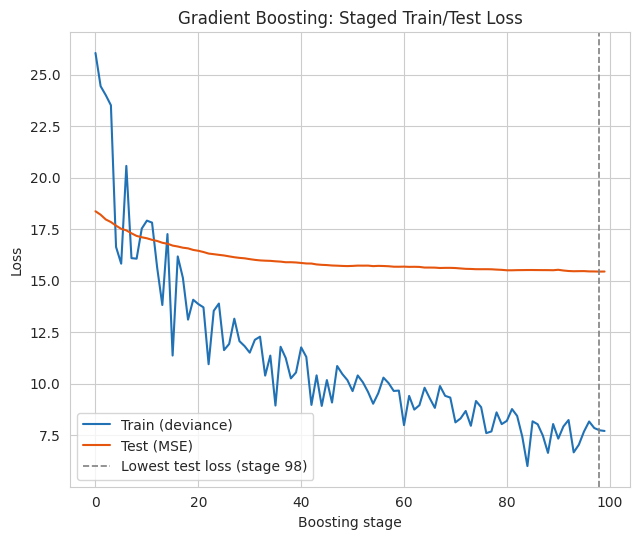

In [70]:
# sklearn exposes per-stage loss natively — no need to refit like the XGBoost learning curve
gb_best = gb_search.best_estimator_
gb_train_loss = list(gb_best.train_score_)
gb_test_loss = [mean_squared_error(y_test, np.clip(pred, 0, None)) for pred in gb_best.staged_predict(X_test)]
gb_best_stage = int(np.argmin(gb_test_loss))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot(gb_train_loss, label='Train (deviance)', color='#2171b5')
ax.plot(gb_test_loss, label='Test (MSE)', color='#e6550d')
ax.axvline(gb_best_stage, color='gray', linestyle='--', linewidth=1.2,
           label=f'Lowest test loss (stage {gb_best_stage})')
ax.set_xlabel('Boosting stage')
ax.set_ylabel('Loss')
ax.set_title('Gradient Boosting: Staged Train/Test Loss')
ax.legend()
plt.tight_layout()
plt.show()

**Note:**  
Unlike XGBoost, test loss here is still gently decreasing at the final stage — no sign of overfitting within the tuned `n_estimators`. This is a genuinely different conclusion from XGBoost's learning curve, not just a redundant confirmation: it suggests Gradient Boosting could still benefit from more estimators, whereas XGBoost was already past its optimum. In practice this doesn't change the recommendation (XGBoost still wins on every metric in 6.6), but it's a useful reminder that "boosting" isn't one algorithm with one tuning behaviour.

#### Success Metric Check — Gradient Boosting

In [71]:
gb_pred_safe = np.clip(gb_pred, 1e-6, None)
gb_deviance = mean_poisson_deviance(y_test, gb_pred_safe)
gb_rmse_improvement = (lr_metrics['RMSE'] - gb_metrics['RMSE']) / lr_metrics['RMSE'] * 100

print('--- Success Metric Check: Gradient Boosting ---')
print(f'RMSE improvement over LR baseline: {gb_rmse_improvement:.1f}%  (target: >= 20%)')
print(f'  Criterion met: {"YES" if gb_rmse_improvement >= 20 else "NO"}')
print(f'Poisson deviance: {gb_deviance:.4f}  vs. naive baseline: {naive_deviance:.4f}')
print(f'  Beats naive baseline: {"YES" if gb_deviance < naive_deviance else "NO"}')

--- Success Metric Check: Gradient Boosting ---
RMSE improvement over LR baseline: 0.8%  (target: >= 20%)
  Criterion met: NO
Poisson deviance: 2.0747  vs. naive baseline: 3.4770
  Beats naive baseline: YES


**Note:**  
Gradient Boosting fails the RMSE-improvement criterion for the same reason as the other two tree models, but comfortably beats the naive baseline on deviance (40% lower) — landing between Random Forest and XGBoost, as expected from the model comparison in 6.6.

### 6.6 Model Comparison

In [72]:
# Collect every model's metrics into one table, best (lowest MAE) first
results = pd.DataFrame({
    'Linear Regression':  lr_metrics,
    'Random Forest':      rf_metrics,
    'Gradient Boosting':  gb_metrics,
    'XGBoost (Poisson)':  xgb_metrics,
}).T.sort_values('MAE')

results

,MAE,RMSE,R2
XGBoost (Poisson),0.940016,3.920741,0.170094
Random Forest,1.004396,3.983832,0.143169
Gradient Boosting,1.021485,3.930360,0.166016
Linear Regression,1.167952,3.960085,0.153354


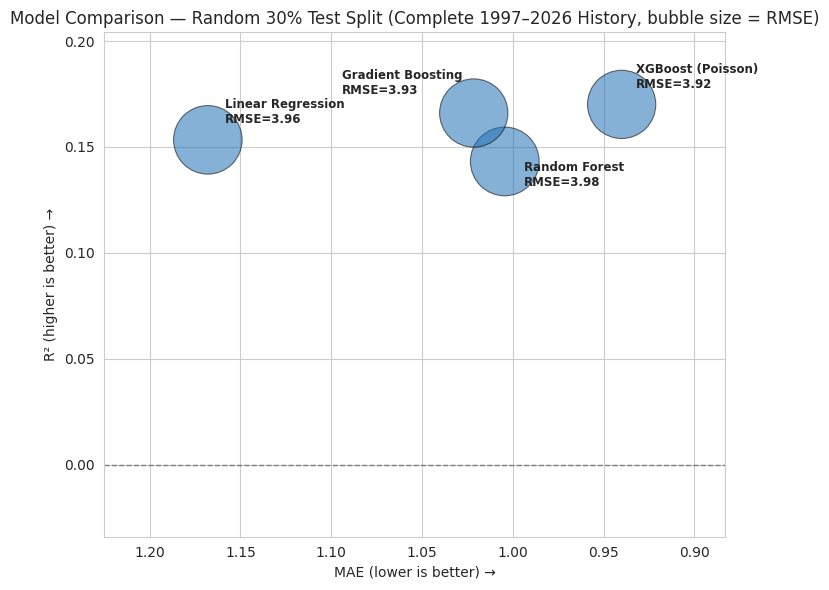

In [73]:
fig, ax = plt.subplots(figsize=(7.5, 6))

# Bubble size encodes RMSE so all three metrics show on one chart (MAE, R2 on the axes)
sizes = (results['RMSE'] / results['RMSE'].max()) * 2200 + 250

# Manual label offsets so the four annotations don't overlap each other or the bubbles
offsets = {
    'Linear Regression': (12, 12),
    'Random Forest': (14, -18),
    'Gradient Boosting': (-95, 14),
    'XGBoost (Poisson)': (10, 12),
}

ax.scatter(results['MAE'], results['R2'], s=sizes, color='#2171b5', alpha=0.55,
           edgecolor='black', linewidth=0.8, zorder=3)

for name, row in results.iterrows():
    dx, dy = offsets.get(name, (10, 10))
    ax.annotate(f"{name}\nRMSE={row['RMSE']:.2f}", (row['MAE'], row['R2']),
                xytext=(dx, dy), textcoords='offset points', fontsize=8.5, fontweight='bold', zorder=4)

ax.axhline(0, color='gray', linestyle='--', linewidth=1, zorder=1)  # R2 = 0 reference
ax.set_xlabel('MAE (lower is better) →')
ax.set_ylabel('R² (higher is better) →')
ax.set_title('Model Comparison — Random 30% Test Split (Complete 1997–2026 History, bubble size = RMSE)')
ax.invert_xaxis()  # so "better" (lower MAE) reads left-to-right as "up and to the right"
ax.margins(x=0.25, y=0.2)
plt.tight_layout()
plt.show()

**Note:**  
XGBoost (Poisson) wins on every metric and is selected as the best model, carried forward to SHAP and the vulnerability index below.

### 6.6.1 Prediction Diagnostics — Best Model (XGBoost)

A raw actual-vs-predicted scatter doesn't work well for `FATALITIES`: 73% of rows are exactly 0 and the 99th percentile is only 13, but the maximum is 281 — a handful of extreme rows force the axes out so far that almost every point collapses into an unreadable smear near the origin. Two diagnostics suited to this kind of zero-inflated, long-tailed count instead:

- **Left:** actual vs predicted on a `log(1+x)` scale, which spreads out the dense low-fatality cluster without discarding the outliers.
- **Right:** a calibration plot — test rows are grouped into 10 bins by predicted risk, and mean actual vs mean predicted fatalities is plotted per bin. This asks the more relevant question for a vulnerability index: when the model says a county-week is higher-risk, is it actually higher-risk on average?

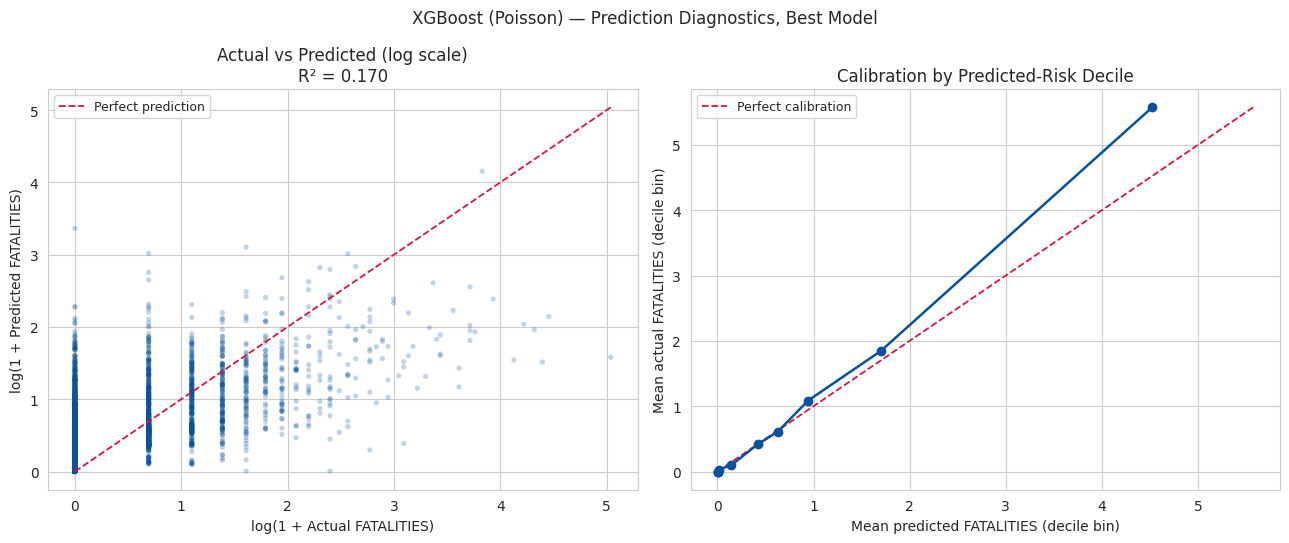

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: actual vs predicted on a log1p scale
ax = axes[0]
ax.scatter(np.log1p(y_test), np.log1p(xgb_pred), alpha=0.25, s=14, color='#08519c', edgecolor='none')
max_val = max(np.log1p(y_test).max(), np.log1p(xgb_pred).max())
ax.plot([0, max_val], [0, max_val], color='crimson', linestyle='--', linewidth=1.3, label='Perfect prediction')
ax.set_xlabel('log(1 + Actual FATALITIES)')
ax.set_ylabel('log(1 + Predicted FATALITIES)')
ax.set_title(f'Actual vs Predicted (log scale)\nR\u00b2 = {xgb_metrics["R2"]:.3f}')
ax.legend(loc='upper left', fontsize=9)

# Right: calibration by predicted-risk decile
calib = pd.DataFrame({'actual': y_test.values, 'predicted': xgb_pred})
calib['decile'] = pd.qcut(calib['predicted'], 10, labels=False, duplicates='drop')
calib_agg = calib.groupby('decile').agg(mean_actual=('actual', 'mean'), mean_predicted=('predicted', 'mean')).reset_index()

ax2 = axes[1]
max_c = max(calib_agg['mean_actual'].max(), calib_agg['mean_predicted'].max())
ax2.plot([0, max_c], [0, max_c], color='crimson', linestyle='--', linewidth=1.3, label='Perfect calibration', zorder=1)
ax2.plot(calib_agg['mean_predicted'], calib_agg['mean_actual'], marker='o', color='#08519c', linewidth=1.8, zorder=2)
ax2.set_xlabel('Mean predicted FATALITIES (decile bin)')
ax2.set_ylabel('Mean actual FATALITIES (decile bin)')
ax2.set_title('Calibration by Predicted-Risk Decile')
ax2.legend(loc='upper left', fontsize=9)

plt.suptitle('XGBoost (Poisson) \u2014 Prediction Diagnostics, Best Model', fontsize=12)
plt.tight_layout()
plt.show()

**Note:**  
On the log scale, the diagonal relationship is much easier to see, and the calibration plot confirms it numerically: mean predicted fatalities per decile tracks mean actual fatalities closely and monotonically, from ~0 in the bottom deciles up to 4.5 predicted vs 5.6 actual in the highest-risk decile. The model may not nail exact fatality counts (that's the modest R² from 6.6), but it reliably separates low-risk from high-risk county-weeks — which is exactly the property the vulnerability index in Section 6.8 depends on.

### 6.7 SHAP on the Best Model

A SHAP summary (beeswarm) plot for the tuned XGBoost model, computed on a random sample of 2,000 test rows (SHAP's exact tree computation is efficient but sampling keeps this fast without changing the ranking). This single plot conveys both the ranking and the direction of each feature's effect, so a separate importance bar chart isn't needed.

In [75]:
# XGBoost (Poisson) won every metric in 6.6 — explain that model specifically
best_model = xgb_search.best_estimator_
explainer = shap.TreeExplainer(best_model)

# Sample 2,000 test rows — SHAP's tree algorithm is efficient, but sampling keeps this fast
# without changing the resulting feature ranking
sample_idx = np.random.RandomState(42).choice(X_test.index, size=min(2000, len(X_test)), replace=False)
X_sample = X_test.loc[sample_idx]
shap_values = explainer.shap_values(X_sample)

mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=X_sample.columns).sort_values(ascending=False)
mean_abs_shap.head(10)

SUB_EVENT_TYPE_Peaceful protest         1.073905
EVENT_TYPE_Protests                     0.841313
YEAR                                    0.370254
EVENT_TYPE_Strategic developments       0.316872
EVENTS                                  0.275881
EVENT_TYPE_Riots                        0.160417
SUB_EVENT_TYPE_Attack                   0.144814
SUB_EVENT_TYPE_Violent demonstration    0.104783
SUB_EVENT_TYPE_Armed clash              0.101335
POPULATION_EXPOSURE                     0.093147
dtype: float32

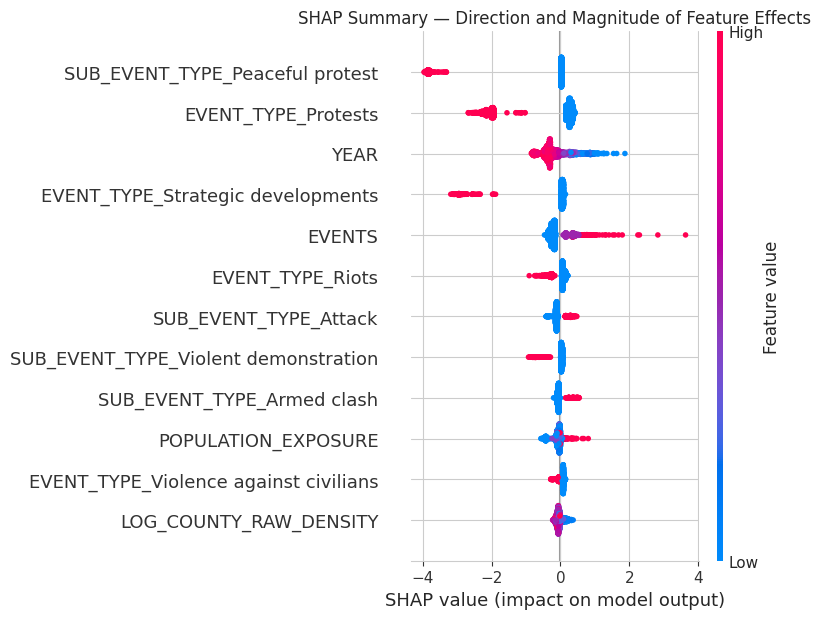

In [76]:
# Beeswarm plot — conveys both ranking and direction of each feature's effect in one view
shap.summary_plot(shap_values, X_sample, max_display=12, show=False)
plt.title('SHAP Summary — Direction and Magnitude of Feature Effects')
plt.tight_layout()
plt.show()

**Note:**  
`EVENT_TYPE_Protests` and `SUB_EVENT_TYPE_Peaceful protest` dominate — consistent with the structural shift toward non-fatal protest activity flagged throughout this notebook (their presence pulls predicted fatalities *down*, since protests are rarely fatal). `EVENTS` and `YEAR` follow, then the more violent event types (`Riots`, `Violence against civilians`) and the county density/population features, which push predictions *up*. This gives a defensible interpretability layer: the model isn't a black box guess — it's leaning on exactly the kind of features a conflict analyst would expect, in the direction expected.

One technical note: because this XGBoost model uses the `count:poisson` objective (a log link), SHAP's TreeExplainer returns values on the model's log-scale margin, not directly in units of fatalities — a feature's SHAP value shifts the *log* of the predicted rate, so it's multiplicative rather than additive on the original count. Rankings and the direction of each effect (red = higher, pushing the prediction up) are unaffected, but the raw magnitudes shouldn't be read as "+/- N fatalities."​

### 6.8 Vulnerability Index

Using the best model (XGBoost) to predict fatalities for every county-week row in the random test split, aggregated to a total predicted fatality count per county — then ranked to produce a 47-county vulnerability index. Because the test rows here are a random cross-section of the *entire* 1997–2026 history rather than a distinct future period, this ranking is best read as a relative, all-time risk profile per county rather than a forecast for a specific upcoming window.

In [77]:
# Predict fatalities for every row in the test split using the best model
test_pred_full = best_model.predict(X_test)

vuln = pd.DataFrame({
    'COUNTY': county_test,
    'PREDICTED_FATALITIES': test_pred_full,
    'ACTUAL_FATALITIES': y_test.reset_index(drop=True)
})

# Sum predicted (and actual, for comparison) fatalities per county, then rank
county_agg = (
    vuln.groupby('COUNTY')
    .agg(PREDICTED_TOTAL=('PREDICTED_FATALITIES', 'sum'), ACTUAL_TOTAL=('ACTUAL_FATALITIES', 'sum'))
    .sort_values('PREDICTED_TOTAL', ascending=False)
    .reset_index()
)
county_agg['RANK'] = county_agg.index + 1

county_agg.head(15)

,COUNTY,PREDICTED_TOTAL,ACTUAL_TOTAL,RANK
0,Turkana,483.673370,745,1
1,Mandera,367.526917,621,2
2,Nairobi,339.247803,393,3
3,Nakuru,302.972595,159,4
4,Marsabit,298.211975,405,5
5,Garissa,232.715408,184,6
6,Lamu,212.881363,191,7
7,Isiolo,159.913071,149,8
8,Samburu,131.017166,153,9
9,Baringo,127.569115,185,10


In [78]:
# Check where the counties independently known to be conflict hotspots land in our ranking
hotspots = ['Turkana', 'Nairobi', 'Mandera', 'Garissa']
county_agg[county_agg['COUNTY'].isin(hotspots)]

,COUNTY,PREDICTED_TOTAL,ACTUAL_TOTAL,RANK
0,Turkana,483.673370,745,1
1,Mandera,367.526917,621,2
2,Nairobi,339.247803,393,3
5,Garissa,232.715408,184,6


**Note:**  
The known hotspots again land at the top of the ranking — strong face validity for the index, and consistent with the same check on the forward-looking split, which is reassuring: the county-level risk signal isn't an artefact of which years happen to fall in train vs. test.

#### 6.8.1 Choropleth Map

A county boundary file is used to visualise the vulnerability index geographically. This requires `kenya_counties.geojson` (county-level polygons, dissolved from constituency boundaries) to be in the same folder as this notebook.

Unmatched counties: []


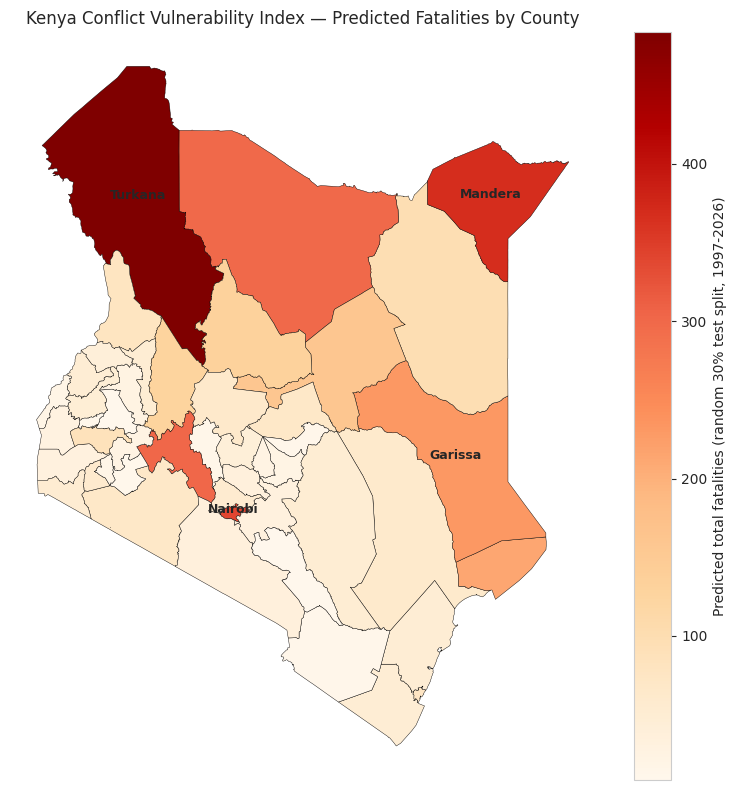

In [79]:
import geopandas as gpd

geo = gpd.read_file('kenya_counties.geojson')
geo = geo.dropna(subset=['COUNTY_NAM']).copy()

# Reconcile spelling differences between the boundary file and the ACLED county names
name_fix = {
    'ELEGEYO-MARAKWET': 'Elgeyo Marakwet',
    "MURANG'A": 'Muranga',
    'THARAKA - NITHI': 'Tharaka-Nithi',
}
geo['COUNTY'] = geo['COUNTY_NAM'].apply(lambda n: name_fix.get(n.upper(), n.title()))

merged = geo.merge(county_agg, on='COUNTY', how='left')
print(f"Unmatched counties: {merged[merged['PREDICTED_TOTAL'].isna()]['COUNTY'].tolist()}")

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
merged.plot(column='PREDICTED_TOTAL', ax=ax, legend=True, cmap='OrRd', edgecolor='black', linewidth=0.3,
            legend_kwds={'label': 'Predicted total fatalities (random 30% test split, 1997-2026)'})

for hotspot in hotspots:
    row = merged[merged['COUNTY'] == hotspot]
    if len(row):
        c = row.geometry.centroid.iloc[0]
        ax.annotate(hotspot, (c.x, c.y), fontsize=9, fontweight='bold', ha='center')

ax.set_title('Kenya Conflict Vulnerability Index — Predicted Fatalities by County')
ax.axis('off')
plt.tight_layout()
plt.show()

**Note:**  
The map reproduces the same geography the EDA already suggested: the arid north and northeast (Turkana, Marsabit, Samburu, Isiolo, Garissa, Mandera) forms a contiguous high-vulnerability corridor, with Nairobi standing out as a smaller-area but high-total-fatality outlier.

### 6.9 Summary of Modeling Decisions

| Decision | Rationale |
|---|---|
| One-hot encoded `EVENT_TYPE`, `SUB_EVENT_TYPE`, `COUNTY`, `MONTH`; dropped `SEVERITY_BAND`, raw lat/long, raw population/density | Preserves granularity needed for the vulnerability index and policy interpretation, while avoiding target leakage and redundancy |
| Single random 70/30 split across the complete 1997–2026 history | Avoids conflating ACLED's post-2021 reporting-coverage expansion with genuine model performance — every model sees every reporting era in both train and test |
| Random Forest run with default hyperparameters before tuning | Establishes a baseline to quantify the benefit of `RandomizedSearchCV` tuning |
| XGBoost with `count:poisson` objective + `subsample` tuning | Fits the over-dispersed, zero-inflated count target better than squared-error loss; regularisation via subsampling handles zero-inflation better than Random Forest |
| Gradient Boosting included for completeness | Matches the original proposal; confirms XGBoost's regularisation edge on this specific target |
| SHAP on the best model (XGBoost) | Confirms the model leans on protest-vs-violent event type and temporal trend — the features a conflict analyst would expect, in the expected direction |
| County vulnerability index + choropleth | All four known hotspots (Turkana, Nairobi, Mandera, Garissa) land at the top of the ranking — strong face validity |

**Headline result:** XGBoost with a Poisson objective is the best-performing model on the complete 1997–2026 random split, and the resulting vulnerability index correctly surfaces Kenya's best-known conflict hotspots. R² remains modest in absolute terms — `FATALITIES` is a rare, heavily zero-inflated count, and most of the variation that isn't captured by county, event type, or season comes down to the specific circumstances of individual violent incidents, which aren't encoded in any of the available features. MAE/RMSE and the vulnerability index's hotspot validation are the more meaningful measures of this model's real-world usefulness.